# **Tutorial REC1**
This tutorial demonstrates how to run a simulation  from the tutorials/example_model folder in the pyRES package.

The tutorial shows how to:

1. Prepare the input files (CSV and YAML).

2. Use the provided config.py script to generate the YAML configuration.

3. Run the simulation using main.py.

4. Generate and analyze the results saved in the Output folder.


----
---

## **Example model Structure**

Below is the structure of the REC1 model located in
tutorials/example_model/

```text
Rec1/
│
├── Input/                       # Simulation input 
│   ├── demand_qc_kw_el.csv      # Demand data (CSV file)
│   └── config.yaml              # Configuration file for the simulation (YAML file)
│
├── Output/                      # Simulation output   
│   ├── prosumer1_electricity_Summer.png   # Seasonal electricity plots per prosumer
│   ├── prosumer1_cashflow_annual.png      # Annual cashflow plot per prosumer
│   ├── prosumer1_cashflow_cumulative.png  # Cumulative cashflow plot per prosumer
│   ├── prosumer1_economic_breakdown.png   # Economic breakdown per prosumer
│   ├── rec1_electricity_bar.png           # Annual energy bar chart per REC
│   ├── prosumers_en_perf_evolution_kW.csv # Time series energy performance (prosumers)
│   ├── recs_en_perf_evolution_kW.csv      # Time series energy performance (RECs)
│   ├── prosumers_ec_perf_€.xlsx           # Economic performance (prosumers)
│   ├── recs_ec_perf_€.xlsx                # Economic performance (RECs)
│   ├── environmental_summary.xlsx         # Environmental performance summary
│   ├── environmental_summary.html         # Environmental performance (HTML report)
│   └── ...                    
│
├── config.py                    # Script to generate config.yaml
├── main.py                      # Main simulation script
└── Rec1.xlsx                    # Excel file summarizing the main parameters 
```


## **Step0- Create Your Own Test Folder**

To test the code, we first create a new folder named jpt_ntb_test inside tutorials/example_model/.
Then, we copy the necessary files from Rec1/ to jpt_ntb_test/.

This cell builds a copy of the Rec1 example model inside jpt_ntb_test, which becomes the working directory for the rest of the notebook.
  - Defines two folders:
    - src_base = tutorials/example_model/Rec1 — the source example model.
    - test_base = tutorials/example_model/jpt_ntb_test — the sandbox where the tutorial actually runs.
  - Creates test_base/Input and test_base/Output if they don't already exist.
  - Copies main.py, config.py, and demand_qc_kw_el.csv from src_base into test_base (files under Input/ go into test_base/Input/, the rest into the test_base root).


In [1]:
from pathlib import Path
import shutil
import os
import sys

# Find project root (works from any launch directory)
root = Path.cwd()
while not (root / 'src').is_dir() and root != root.parent:
    root = root.parent
os.chdir(root)
sys.path.insert(0, str(Path.cwd()))

src_base = Path("tutorials/example_model/Rec1")
test_base = Path("tutorials/example_model/jpt_ntb_test")

(test_base / "Input").mkdir(parents=True, exist_ok=True)
(test_base / "Output").mkdir(parents=True, exist_ok=True)

files = [
    src_base / "main.py",
    src_base / "config.py",
    src_base / "Input" / "demand_qc_kw_el.csv",
]

copied = []

for src in files:
    if src.exists():
        if "Input" in src.parts:
            dst = test_base / "Input" / src.name
        else:
            dst = test_base / src.name
        shutil.copy2(src, dst)
        copied.append(str(dst))

---
---

## **Step1- Prepare Input Data**

Before running a simulation, you need two input files inside the Input/ folder:

- demand_qc_kw_el.csv:

    - This file contains the energy demand profiles (kW) for all consumers and prosumers.
    
    - Each column represents a different user profile (e.g. supermarket, school, residential, …).
    
    - Each row represents a time step (e.g. 15 minutes).
    
    - All columns must have the same length, which depends on the analyzed period and the chosen time resolution.
    For example: One year with a 15-minute resolution → 35,040 rows, One year with an hourly resolution → 8,760 rows.
      
    - The prosumer profiles should be placed first, followed by the consumer profiles. In this tutorial user0 and user1 are prosumers, while user2 to user51 are consumers.

- config.yaml:
    
   - This file defines the simulation parameters: systems, consumers, prosumers, and the energy community.

   - It can be generated automatically using the config.py script below.

---
---

## **Step2 - Generate the YAML Configuration**

The script config.py automatically creates a ready-to-use config.yaml file inside the Input/ folder.


Python module to read and write YAML files

In [2]:
import yaml

Path to CSV with demand data (kW) for all consumers and prosumers.

In [3]:
demand_file = os.path.join("Input/demand_qc_kw_el.csv")

In [4]:
simulation_dict={
        "time_step": '15min', "start_date": '01-01-2020', 'time_horizon': 20, "demand_curve_file": demand_file

    }

simulation_dict is a dictionary that contains the main simulation parameters:

- time_step: defines the temporal resolution, meaning that the model processes data in 15-minute intervals. This determines how often the energy demand, production, and other variables are updated.
- start_date :  indicates the starting date of the simulation period. (DD-MM-YYYY)
- time_horizon → 20 represents the time horizon for economic analysis

demand_curve_file → path to CSV with demand data


In [5]:
users_dict = {}

users_dict is a dictionary that contain demand profiles imported from demand_qc_kw_el.csv.


Multiple users are automatically added to the users_dict.
- id: a code that uniquely identifies each user (id0, id1, …, id51)
- carriers: energy vector
- column: name of the column in demand_qc_kw_el.csv where the user’s demand curve is stored (user0, user1, …, user52)


In [6]:
n_users = 52

for i in range(n_users):
    users_dict[f"user{i}"] = {
        "id": f"{i}",
        "carriers": {
            "electricity": {
                "column": f"user{i}"
            }
        }
    }


users_dict["user_rec"] = {
    "id": "rec_load",
    "carriers": {
        "electricity": {
            "column": "user2"
        }
    }
}

Create a list of consumers based on the profiles imported in the dictionary dict_users. From user2 to user51 are consumers.

In [7]:
consumers_list = [f"user{i}" for i in range(2, n_users)]

Set PV default parameters, default value --> module NeON 2 LG370Q1C-V5 (370W, 72 celle)

In [8]:
pv_module_params = {
    "isc_ref": 10.47,       # (A) The module's short circuit current reported on the manufacturer's spec sheet. Reference conditions are typically 1000 W/m2 (incident solar radiation) and 25°C (ambient temperature)
    "voc_ref": 49.3,        # (V) The module's open circuit voltage reported on the manufacturer's spec sheet.
    "vmppt_ref": 40.6,      # (V) (V) The module's maximum power point voltage reported on the manufacturer's spec sheet
    "imppt_ref": 9.86,      # (A) The module's maximum power point current reported on the manufacturer's spec sheet
    "mu_isc_ref": 0.02,     # (A/K) Temperature coefficient of Isc (ref. cond)
    "mu_voc_ref": 0.26,     # (V/K) Temperature coefficient of Voc (ref. cond)
    "ser_cell": 60,         # number of cells wired in series
    "t_cell_noct_c": 42,    # (°C) Module temperature at NOCT
    "area": 2.07,           # (m^2) (m^2) module area
    "eg": 1.12,
    "dc_ac_efficiency": 0.97,  # inverter efficiency DC/AC
    "mismatch_loss": 0.02,     # mismatch losses
    "wiring_loss": 0.015,      # cable losses (1.5%)
    "soiling_loss": 0.03,      # soiling losses (3%)
}


The PVPanels class includes parameters that describe the technical and economic characteristics of a photovoltaic system.
By default, these parameters are initialized using a reference datasheet (file/NeON_2_72_90214.pdf).
If you want to model a different PV module, update the corresponding values:
- isc_ref=10.47 (A): The module's short circuit current. Reference conditions are typically 1000 W/m2 (incident solar radiation) and 25 °C (ambient temperature)
- voc_ref=49.3 (V): module's open circuit voltage.
- vmppt_ref=40.6 (V): module's maximum power point voltage
- imppt_ref=9.86 (A): module's maximum power point current
- mu_isc_ref=0.02 (A/K) : temperature coefficient of Isc (ref. cond)
- mu_voc_ref=0.26 (V/K) : temperature coefficient of Voc (ref. cond)
- t_cell_noct_c=42 °C : module temperature at NOCT
- area=2.07 (m&#178;): module area
- eg=1.12 (eV): material bandgap energy (1.12 for c-Si, 1.35 for GaAs, 1.45 for CdTe)
- dc_ac_efficiency: inverter DC-to-AC conversion efficiency (typical 0.96-0.98)
- mismatch_loss: fractional power loss due to module mismatch (typical 0.01-0.02)
- wiring_loss: fractional power loss in DC/AC wiring (typical 0.01-0.02)
- soiling_loss: fractional power loss due to soiling/dirt (typical 0.02-0.05)


Create a dictionary containing production systems

In [9]:
systems_dict = {'pv1':
                    {'tech': {"id": "pv1", "lat": 41.9027835,
                              "lon": 12.496365, "n_series": 30, "n_parallel": 10, "tilt": 30, "azimuth": 0,
                              **pv_module_params},
                     'economics': {'cap_cost': 1000, 'opex_cost': 40, 'inc_year': min(0.5*30*10*0.4*1000,96000)/10, 'inc_start_end': [1, 10],
                                   'tax_year': 0, 'other_cost': {'item1': {'unit': 30*10*0.4, 'cost_unit': 350, 'dur': [10, 10]}},
                                   'other_rev': {'item1': {'unit': 0, 'rev_unit': 0, 'dur': [0, 0]}}}, },
                'pv2':
                    {'tech': {"id": "pv1", "lat": 41.891159,
                              "lon": 12.492059, "n_series": 13, "n_parallel": 12, "tilt": 30, "azimuth": 0,
                              **pv_module_params},
                     'economics': {'cap_cost': 1000, 'opex_cost': 40, 'inc_year': min(0.5*13*12*0.4*1000,96000)/10, 'inc_start_end': [1, 10],
                                   'tax_year': 0, 'other_cost': {'item1': {'unit': 13*12*0.4, 'cost_unit': 350, 'dur': [10, 10]}},
                                   'other_rev': {'item1': {'unit': 0, 'rev_unit': 0, 'dur': [0, 0]}}}, },
                'pv3':
                    {'tech': {"id": "pv1", "lat": 41.893483,
                              "lon": 12.492477, "n_series": 11, "n_parallel": 11, "tilt": 30, "azimuth": 0,
                              **pv_module_params},
                     'economics': {'cap_cost': 1000, 'opex_cost': 40, 'inc_year':0, 'inc_start_end': [0, 0],
                                   'tax_year': 0, 'other_cost': {'item1': {'unit': 11*11*0.4, 'cost_unit': 350, 'dur': [10, 10]}},
                                   'other_rev': {'item1': {'unit': 0, 'rev_unit': 0, 'dur': [0, 0]}}}, }
                }

systems_dict is a dictionary containing production systems. Each system is defined by tech and economic parameters.  
**Technical parameters:**
- id: a code that uniquely identifies each system (pv1,pv2)
- lat, lon: geographic coordinates (World Geodetic System 84 (WGS 84))
- n_series, n_parallel: number of modules in series and parallel
- tilt: panel tilt angle from horizontal (°C)
- azimuth:  panel horizontal orientation (°C)

**Economic parameters:**
- cap_cost: initial cost (€/kW)
- opex_cost: operational cost (€/kW)
- inc_year: incentive value per year (€/year)
- inc_start_end: incentive start and end year. e.g: 'inc_year':min(0.5x720x2.560x2x2,96000)/10, 'inc_start_end': [1, 10], simulates the Bonus50% that provides a 50% of the initial component cost, with a maximum limit of 96,000 €, and this amount is distributed over 10 years (from year 1 to year 10).
- tax_year:  taxes (€/year). It is a fixed tax amount that remains constant every year throughout the analysis period.
- other_cost:  is a dictionary used to define additional costs. Each entry (e.g. 'item1') includes:
    - unit: the unit of measurement for the cost (e.g., kWh, kg, etc.)
    - cost_unit: the unit cost value (e.g €/kWh, €/kg, etc.)
    - dur: a list representing the start and end of the cost duration 
    - e.g. {'item1': {'unit': 30x10x0.4, 'cost_unit': 350, 'dur': [10, 10]}} simulates the inverter replacement, a cost of 350 €/kW per 62.4 kW will be added at year 10. 
- other_rev: is a dictionary used to define additional revenues. Each entry (e.g. 'item1') includes:
    - unit: the unit of measurement for the revenue (e.g. kWh, kg, etc.)
    - rev_unit: the unit revenue value (e.g €/kWh, €/kg, etc.)
    - dur: a list representing the start and end of the revenue duration.
    - e.g. {'item1': {'unit': 50, 'rev_unit': 4, 'dur': [1, 2]}} from year1 to year2 an additional revenue of 200 € will be applied.

Set bess parameters in common

In [ ]:
bess_common_tech_params = {
    'eta_charge': 0.95,
    'eta_discharge': 0.95,
    'self_discharge_rate_per_hour': 0.00004,
    'lifetime_years': 15
}

The common parameters for BESS include:
- eta_charge=0.95, eta_discharge=0.95: Charge/discharge efficiency (round-trip ~90%)
- self_discharge_rate_per_hour=0.00004: Self-discharge rate (~3%/month)
- lifetime_years=15: Battery lifetime for replacement cost calculation

Create a dictionary containing bess systems

In [ ]:
bess_dict = {'bess1':
                 {'tech': {"id": "bess1", 'cap': 10.24, 'c_rate': 1.0,
                           'soc_in': 0.2, 'soc_max': 0.8, 'soc_min': 0.2,
                           'eta_charge': 0.95,
    'eta_discharge': 0.95,
    'self_discharge_rate_per_hour': 0.00004,
    'lifetime_years': 15},
                  'economics': {'cap_cost': 450, 'opex_cost': 20, 'inc_year': min(0.5*450*2.560*2*2,96000)/10, 'inc_start_end': [1, 10],
                                'tax_year': 10, 'other_cost': {'item1': {'unit': 0, 'cost_unit': 0, 'dur': [0, 0]}},
                                'other_rev': {'item1': {'unit': 0, 'rev_unit': 0, 'dur': [0, 0]}}}, },
             'bess2':
                 {'tech': {"id": "bess2", 'cap': 10.24, 'c_rate': 1.0,
                           'soc_in': 0.2, 'soc_max': 1, 'soc_min': 0.2,
                           **bess_common_tech_params},
                  'economics': {'cap_cost': 450, 'opex_cost': 20, 'inc_year':min(0.5*450*2.560*2*2,96000)/10, 'inc_start_end': [1, 10],
                                'tax_year': 10, 'other_cost': {'item1': {'unit': 0, 'cost_unit': 0, 'dur': [0, 0]}},
                                'other_rev': {'item1': {'unit': 0, 'rev_unit': 0, 'dur': [0, 0]}}}, },
             'bess3':
                 {'tech': {"id": "bess2", 'cap': 10.24, 'c_rate': 1.0,
                           'soc_in': 0.2, 'soc_max': 1, 'soc_min': 0.2,
                           **bess_common_tech_params},
                  'economics': {'cap_cost': 450, 'opex_cost': 20, 'inc_year': 0, 'inc_start_end': [0, 0],
                                'tax_year': 10, 'other_cost': {'item1': {'unit': 0, 'cost_unit': 0, 'dur': [0, 0]}},
                                'other_rev': {'item1': {'unit': 0, 'rev_unit': 0, 'dur': [0, 0]}}}, }
             }

bess_dict is a dictionary containing energy storage systems (bess1). Each bess is defined by tech and economic parameters.  

**Technical parameter:**
- id: a code that uniquely identifies each system (bess1)
- cap: total battery capacity (kWh)
- c_rate: C-rate for max charge/discharge power (default 1.0, meaning P_max = cap * c_rate)
- soc_in: initial state of charge (e.g 0.2 means 20% of the total capacity)
- soc_max: max. state of charge
- soc_min: min. state of charge
- eta_charge: charging efficiency (0-1, typical 0.92-0.97). Models energy losses during charging.
- eta_discharge: discharging efficiency (0-1, typical 0.92-0.97). Models energy losses during discharging. Round-trip efficiency = eta_charge × eta_discharge.
- self_discharge_rate_per_hour: self-discharge rate per hour (typical 0.00004 for Li-ion, ~3%/month). Models gradual SOC loss even without load.
- lifetime_years: battery lifetime in years (typical 10-15 for Li-ion). If lifetime < time_horizon, a replacement cost is added in the economic analysis.

**Economic parameters:**
- cap_cost: initial cost (€/kWh)
- opex_cost: operational cost (€/kWh)
- inc_year: incentive value per year (€/year)
- inc_start_end: incentive start and end year. e.g: 'inc_year':min(0.5x720x2.560x2x2,96000)/10, 'inc_start_end': [1, 10], simulates the Bonus50% that provides a 50% of the initial component cost, with a maximum limit of 96,000 €, and this amount is distributed over 10 years (from year 1 to year 10).
- tax_year:  taxes (€/year). It is a fixed tax amount that remains constant every year throughout the analysis period.
- other_cost:  is a dictionary used to define additional costs. Each entry (e.g. 'item1') includes:
    - unit: the unit of measurement for the cost (e.g. kWh, kg, etc.)
    - cost_unit: the unit cost value (e.g. €/kWh, €/kg, etc.)
    - dur: a list representing the start and end of the cost duration 
    - e.g. {'item1': {'unit': 2.560x2x2, 'cost_unit': 720, 'dur': [10, 10]}} simulates the battery replacement, a cost of 720 €/kWh per 4 batteries, each with a capacity of 2.560 kWh, will be added at year 10. 
- other_rev: is a dictionary used to define additional revenues. Each entry (e.g., 'item1') includes:
    - unit: the unit of measurement for the revenue (e.g. kWh, kg, etc.)
    - rev_unit: the unit revenue value (e.g €/kWh, €/kg, etc.)
    - dur: a list representing the start and end of the revenue duration.
    - e.g. {'item1': {'unit': 50, 'rev_unit': 4, 'dur': [1, 2]}} from year1 to year2 an additional revenue of 200 € will be applied.

Create a dictionary containing prosumers

In [10]:
prosumers_dict = {
    "prosumer1": {'tech': {'id': 'prosumer1', 'carriers': ['electricity'], 'users': ['user0'],
                           'systems': ['pv1'],
                           'bess': ['bess1','bess2']},
                  "economics": {
                      "tax_rate": 0.2,
                      "int_rate": 0.05, 'carriers_and_costs': {
                          'electricity': {'decay': 0.02, 'price_buy': 250, 'price_sold': 104}},
                      'other_capex_perc': [0]

                  }},
    "prosumer2": {'tech': {'id': 'prosumer2', 'carriers': ['electricity'], 'users': ['user1'],
                           'systems': ['pv2'],
                           'bess': []},
                  "economics": {
                      "tax_rate": 0.2,
                      "int_rate": 0.05, 'carriers_and_costs': {
                          'electricity': {'decay': 0.02, 'price_buy': 250, 'price_sold': 104}},
                      'other_capex_perc': [0.02]

                  }}
}

prosumers_dict is a dictionary containing prosumers. Each system is defined by tech and economic parameters.  
- id: a code that uniquely identifies each prosumer (prosumer1,prosumer2)
- carriers: energy vectors assigned to the prosumer
- users: demand curve assigned to the prosumer, previously defined in users_dict.
- systems: system  assigned to the prosumer, previously defined in systems_dict.
- bess: bess assigned to the prosumer, previously defined in bess_dict.
- tax_rate: tax on revenues from sale (e.g 0.2 means 20% of taxes on revenues from electricity sale to the supplier)
- int_rate: interest rate for calculating the Net Present Value (e.g 0.03)
- carriers_and_costs: dictionary defining the energy carriers used by the prosumer and their associated costs
    - decay: annual decay rate of the energy production (e.g 0.02 means 2‰ decay per year)
    - price_buy: price for buying energy from the grid (€/MWh)
    - price_sold: price for selling energy to the grid (€/MWh)
- other_capex_perc: A percentage of the initial costs that is added to the purchase value of PV panels and BESS. This can account for additional expenses including infrastructure, design and engineering costs, or other miscellaneous upfront investments. (e.g 0.2 means 20% of additional costs on the initial capex)

Prosumer1 is equipped with one photovoltaic system (pv1) and two battery energy storage systems (bess1 and bess2). These two batteries are composed of four modules, connected in pairs electrically, and then managed in cascade according to their state of charge (SOC). This means that the batteries operate sequentially — for example, one pair charges or discharges first, and the second pair intervenes only when needed — optimizing efficiency and battery lifetime.

Prosumer2, is equipped with one photovoltaic system (pv1) and no battery storage.

Create a dictionary containing rec

In [11]:
rec_dict = {'rec1': {'tech': {
    "id": "rec1",
    'carriers': ['electricity'],
    'prosumers': ['prosumer1', 'prosumer2'],
    'consumers': consumers_list,
    'rec_systems': ['pv3'], 'bess': ['bess3'],
    'rec_users': ['user_rec']},

    "economics": {
        "tax_rate": 0.2,
        "int_rate": 0.05,
        'carriers_and_costs': {'electricity': {'decay': 0.02, 'price_buy': 250, 'price_sold':104}},
        'other_capex_perc': [0.02]

    }
}}

rec_dict is a dictionary containing Rec (rec1). Each Rec is defined by tech and economic parameters.  
- id: a code that uniquely identifies each rec (rec1)
- carriers: energy vectors assigned to the rec
- prosumers: prosumers assigned to the rec, previously defined in prosumers_dict.
- consumers:  consumers assigned to the rec, previously defined in consumers_list.
- rec_systems: system  assigned to the rec, previously defined in systems_dict.
- bess: bess assigned to the rec, previously defined in bess_dict.
- rec_users (optional): loads directly connected to the REC's own production systems. These are electrical loads physically served by the REC's systems (e.g. pv3, bess3) before any surplus is shared with the community. Only these loads generate self-consumption savings and grid purchase costs attributable to the REC as a legal entity. If omitted, the REC has no own load and its economic balance only includes revenues from energy sale and incentives.
- tax_rate: tax on revenues from sale (e.g 0.2 means 20% of taxes on revenues from electricity sale to the supplier)
- int_rate: interest rate for calculating the Net Present Value (e.g 0.03)
- carriers_and_costs: dictionary defining the energy carriers used by the prosumer and their associated costs
    - decay: annual decay rate of the energy production (e.g 0.02 means 2‰ decay per year)
    - price_buy: price for buying energy from the grid (€/MWh)
    - price_sold: price for selling energy to the grid (€/MWh)
- other_capex_perc: A percentage of the initial costs that is added to the purchase value of PV panels and BESS. This can account for additional expenses including infrastructure, design and engineering costs, or other miscellaneous upfront investments. (e.g 0.2 means 20% of additional costs on the initial capex)

The REC includes two prosumers (prosumer1 and prosumer2) — who contribute energy production through their own photovoltaic systems and also consume energy from the community. It also includes 50 consumers who only consume energy without producing it. The community itself is equipped with a photovoltaic system (pv3), a battery energy storage system (bess3), and an electrical load (user_rec) directly connected to its own systems. This load represents, for example, a shared facility such as a community center or common area lighting, whose consumption is served first by the REC's PV and BESS before purchasing from the grid.

Create a dictionary containing simulation details

In [12]:
config_data = {
    "simulation": simulation_dict,

    "users": [users_dict],

    "systems": [systems_dict]
    ,
    "bess": [bess_dict]
    ,
    "prosumers": [prosumers_dict],

    "rec": [rec_dict]
}


Generate the YAML file named config.yaml and save it in:
```text
tutorials/example_model/"test_base"/Input/
```

In [13]:
with open(os.path.join(test_base,"Input/config.yaml"), "w") as file:
    yaml.dump(config_data, file, sort_keys=False)
print("✅ File 'config.yaml' successfully created.")

✅ File 'config.yaml' successfully created.



Generate the YAML file named config.yaml and save it in:
```text
tutorials/example_model/"test_base"/Input/
```


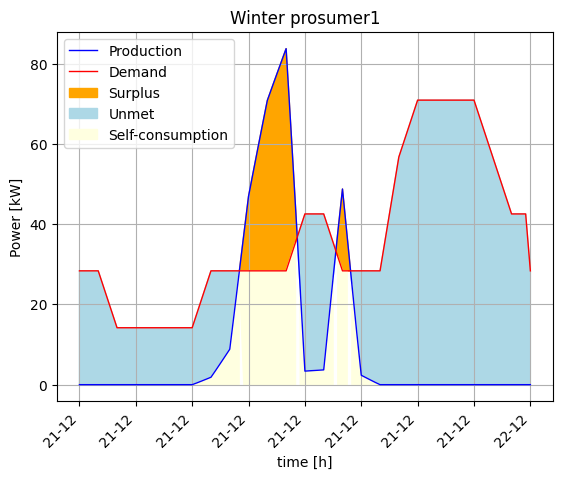

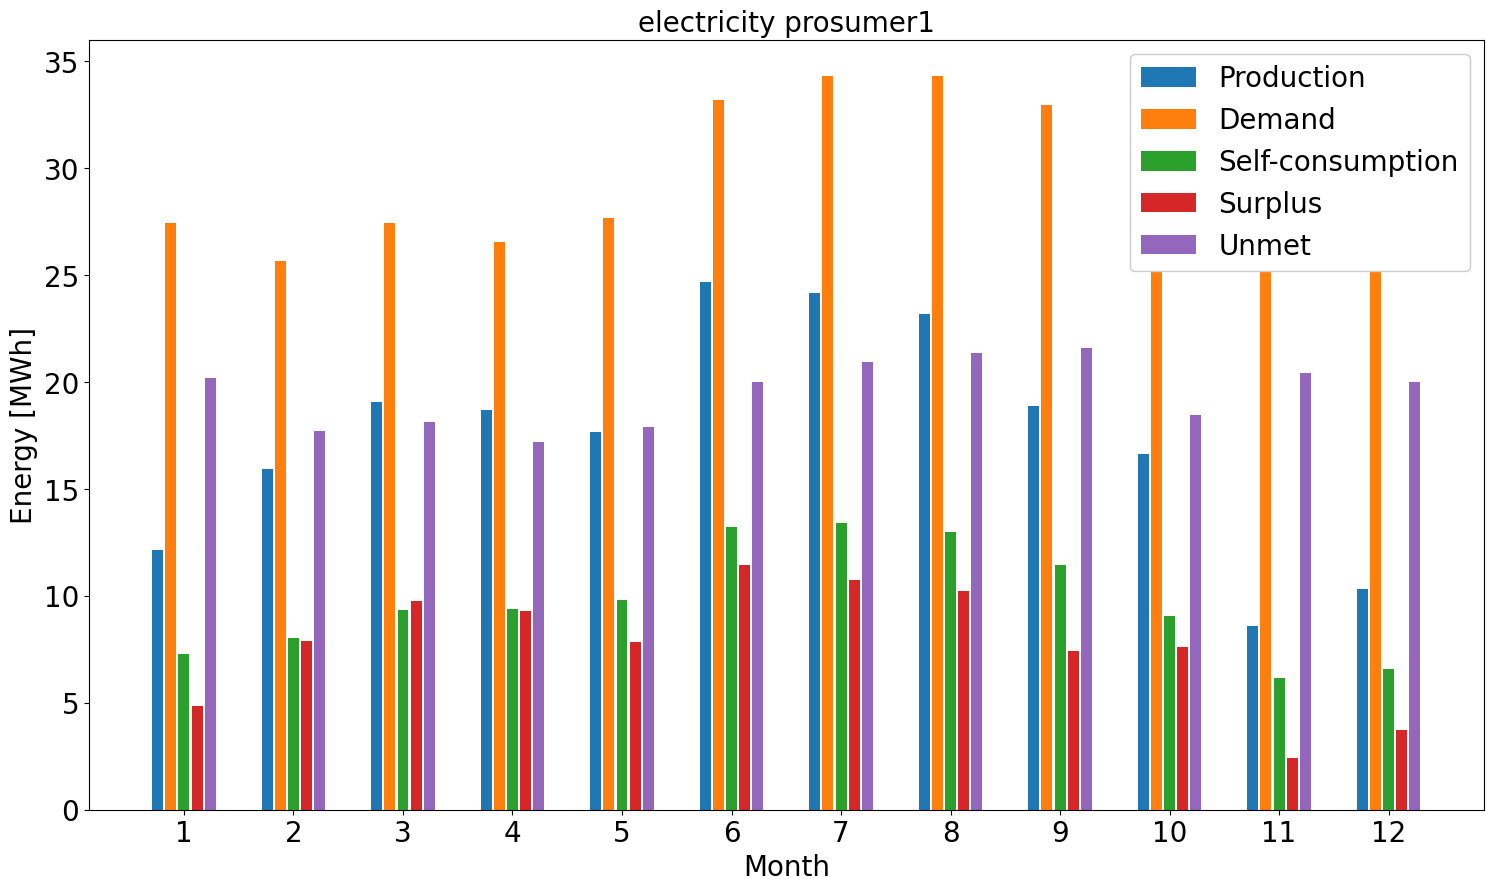

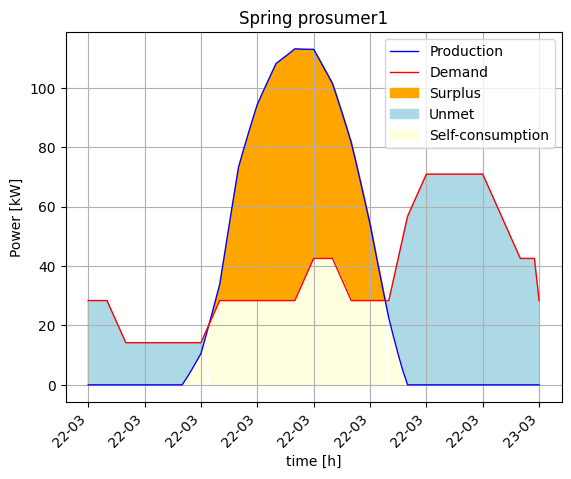

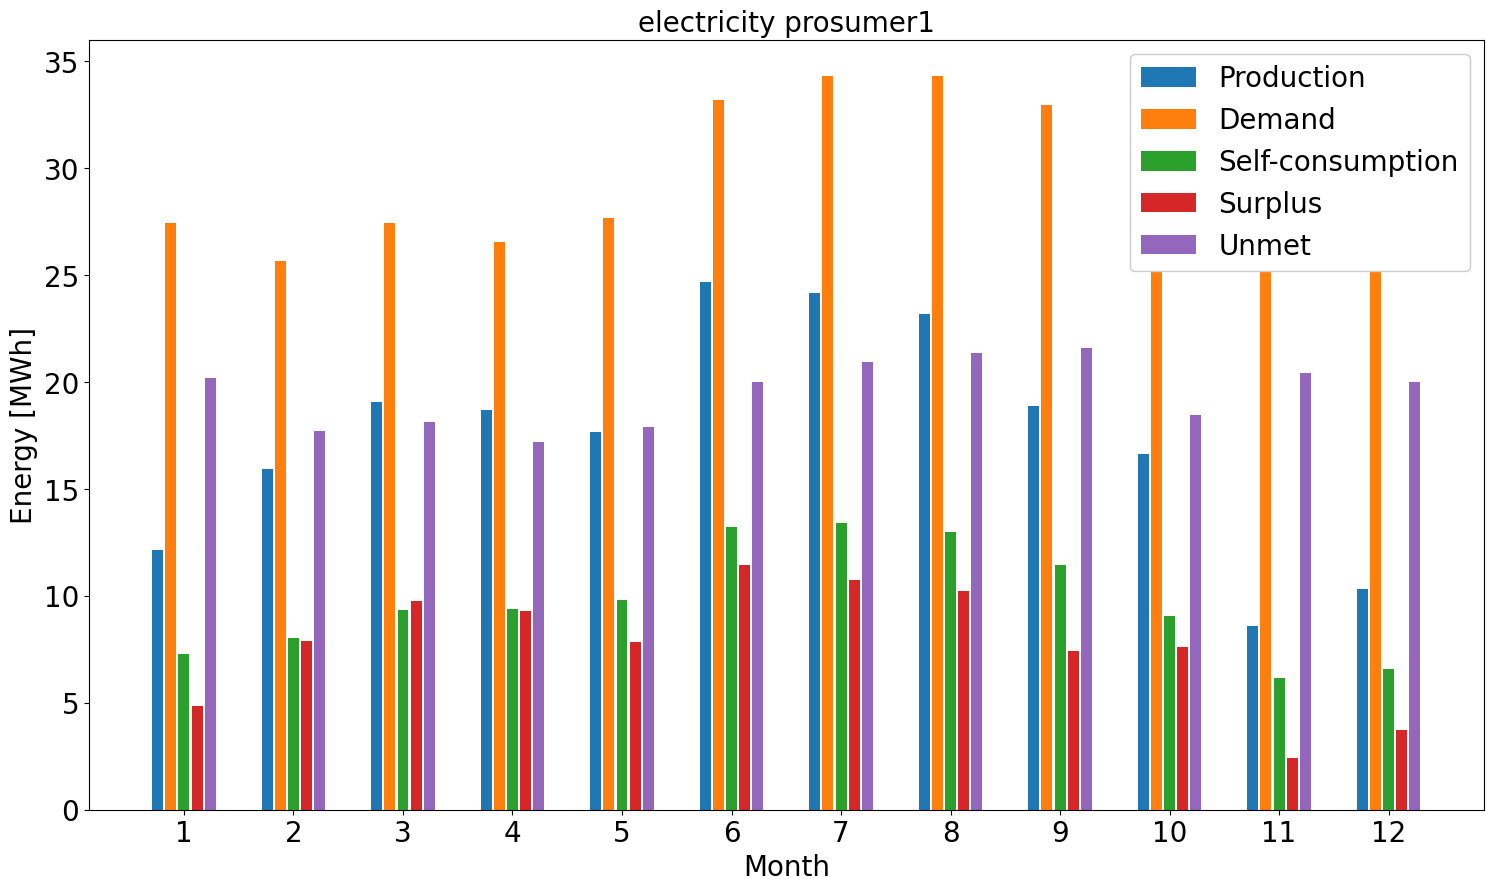

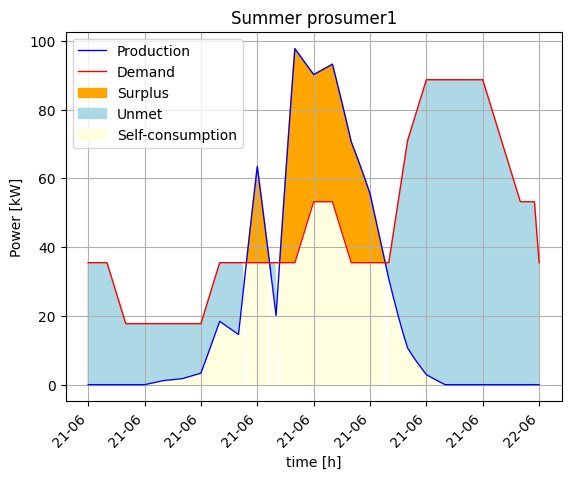

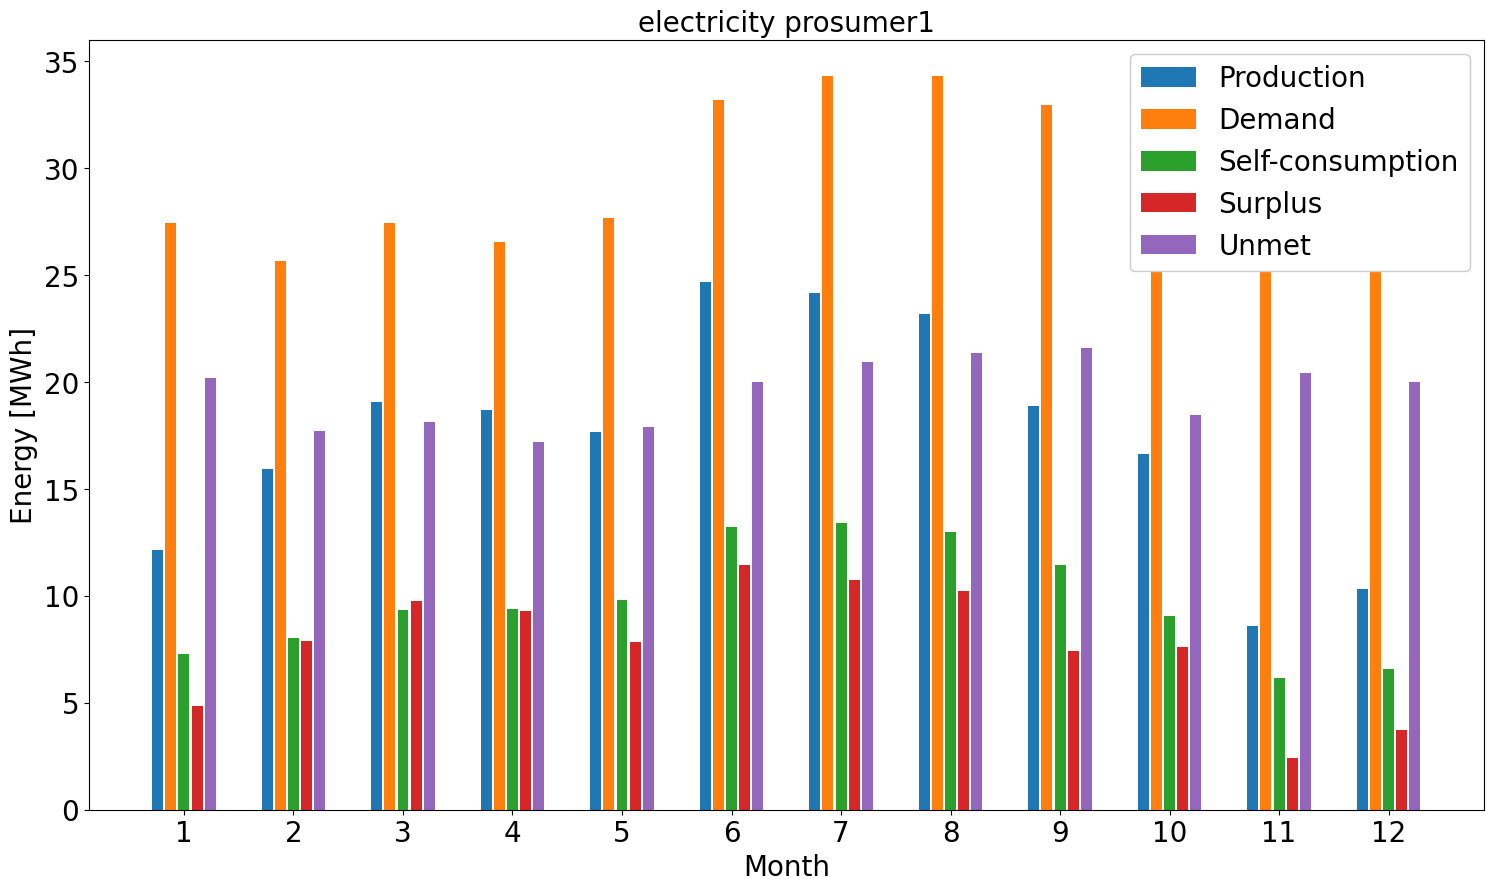

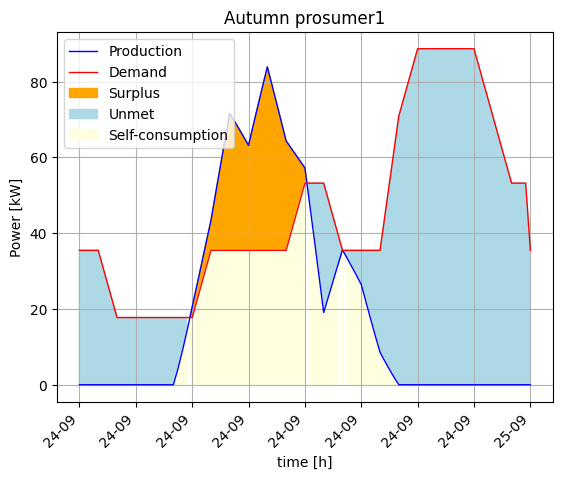

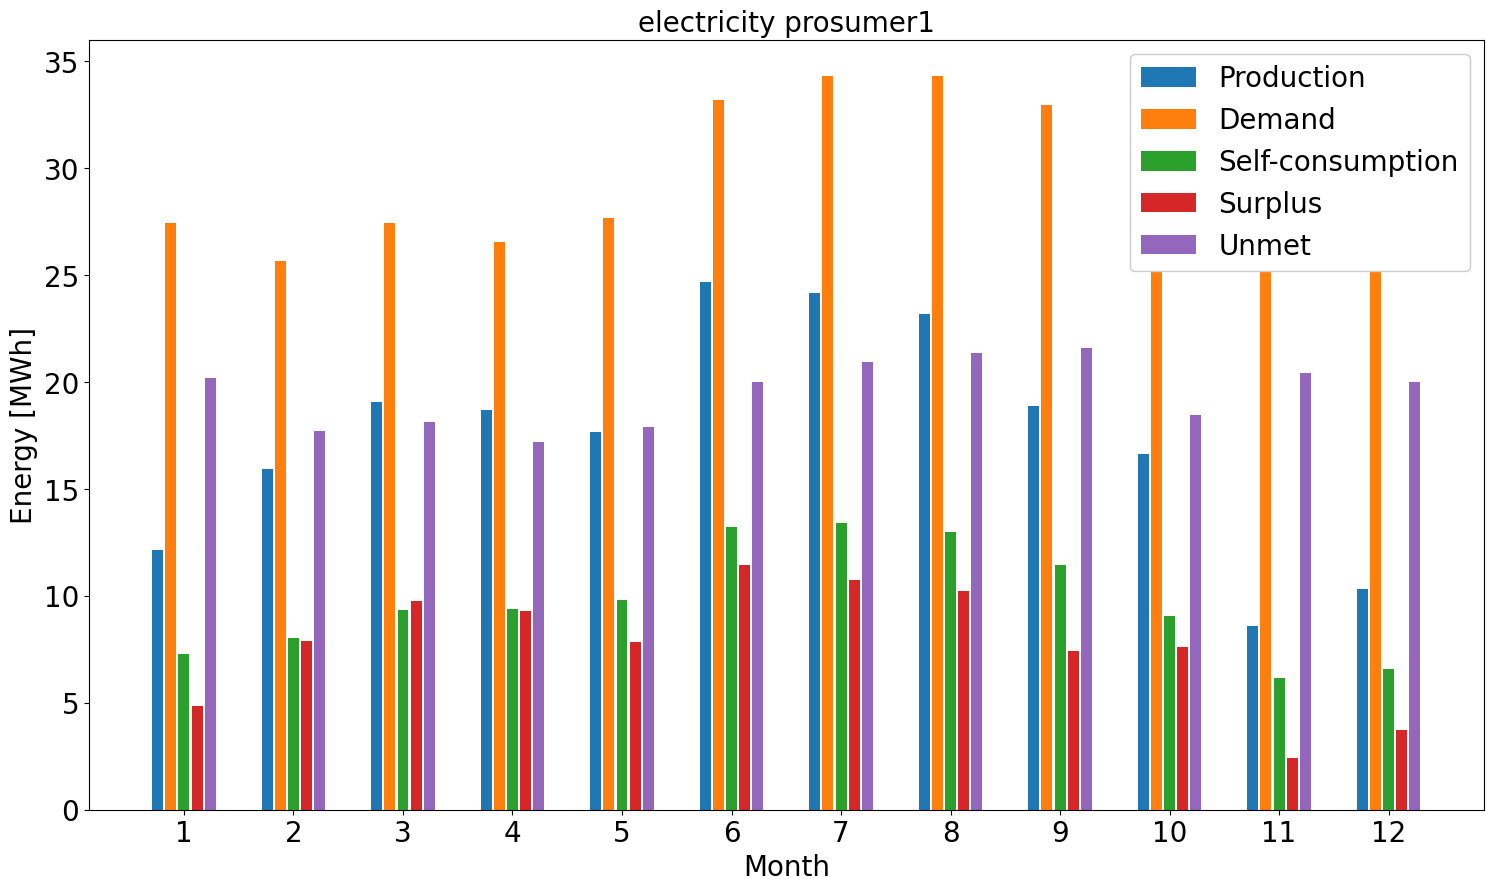

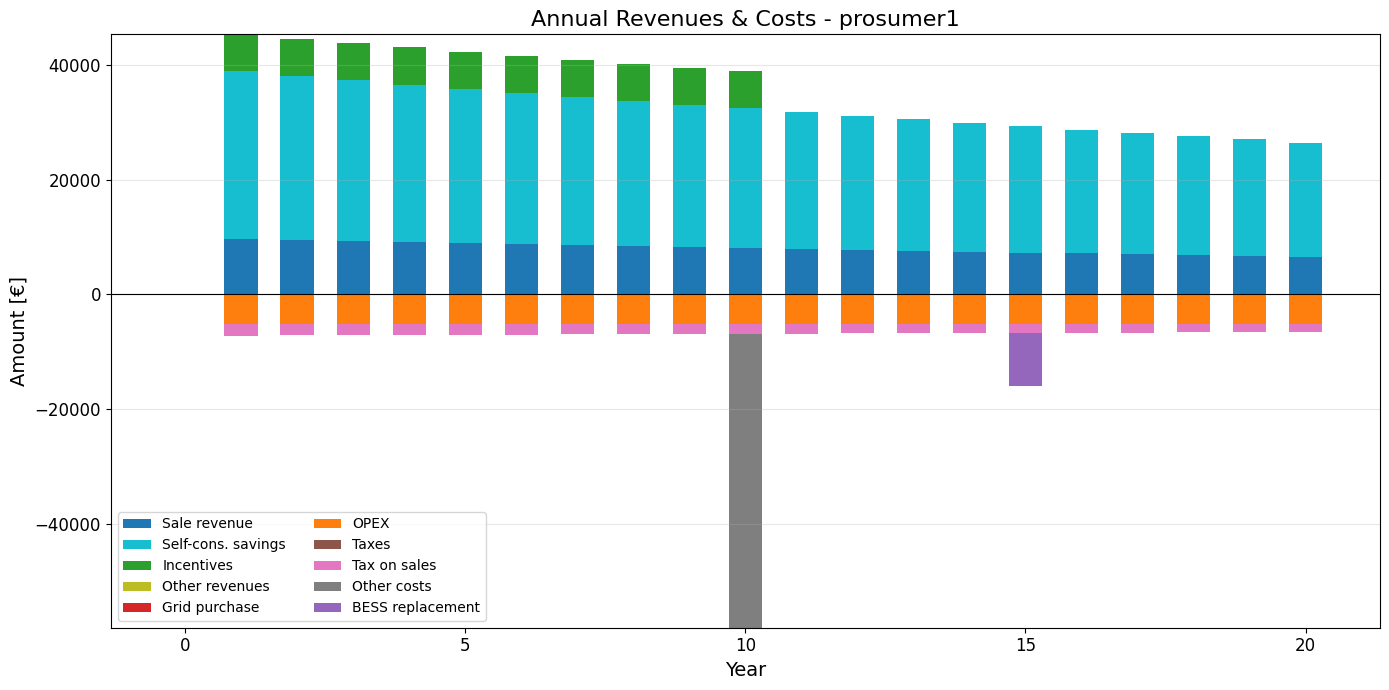

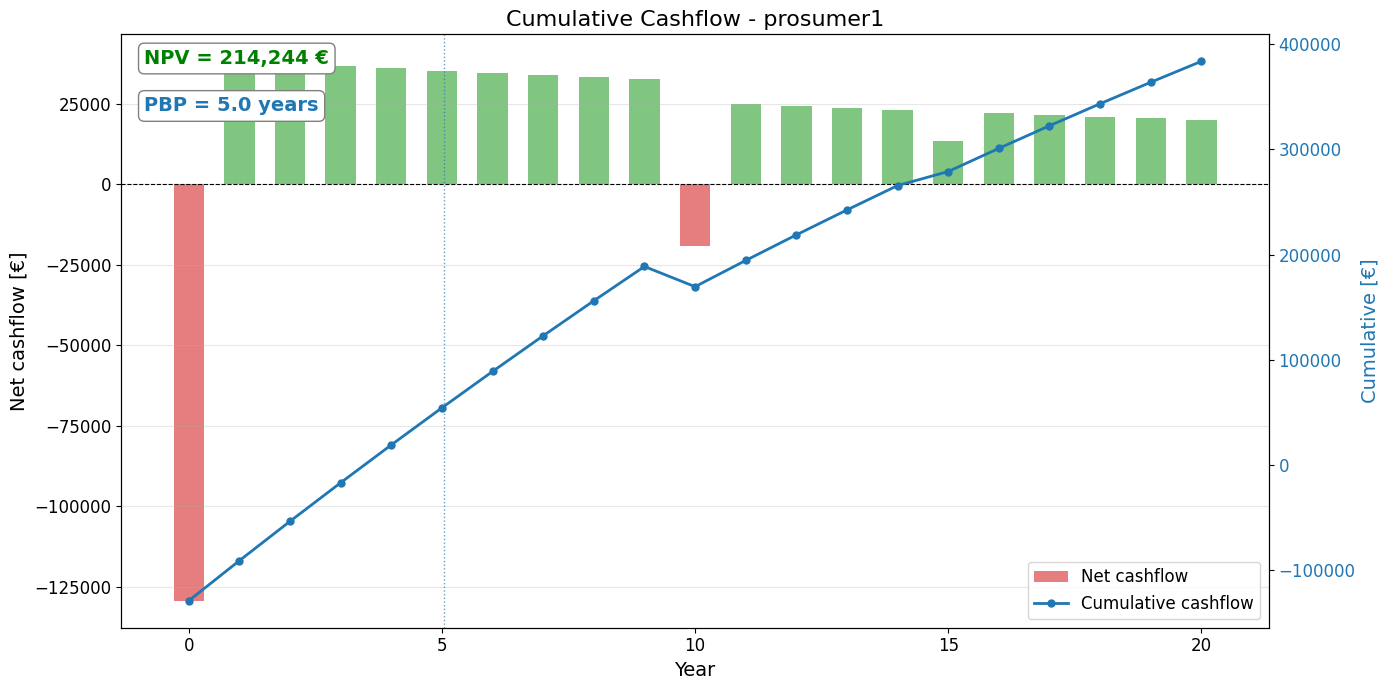

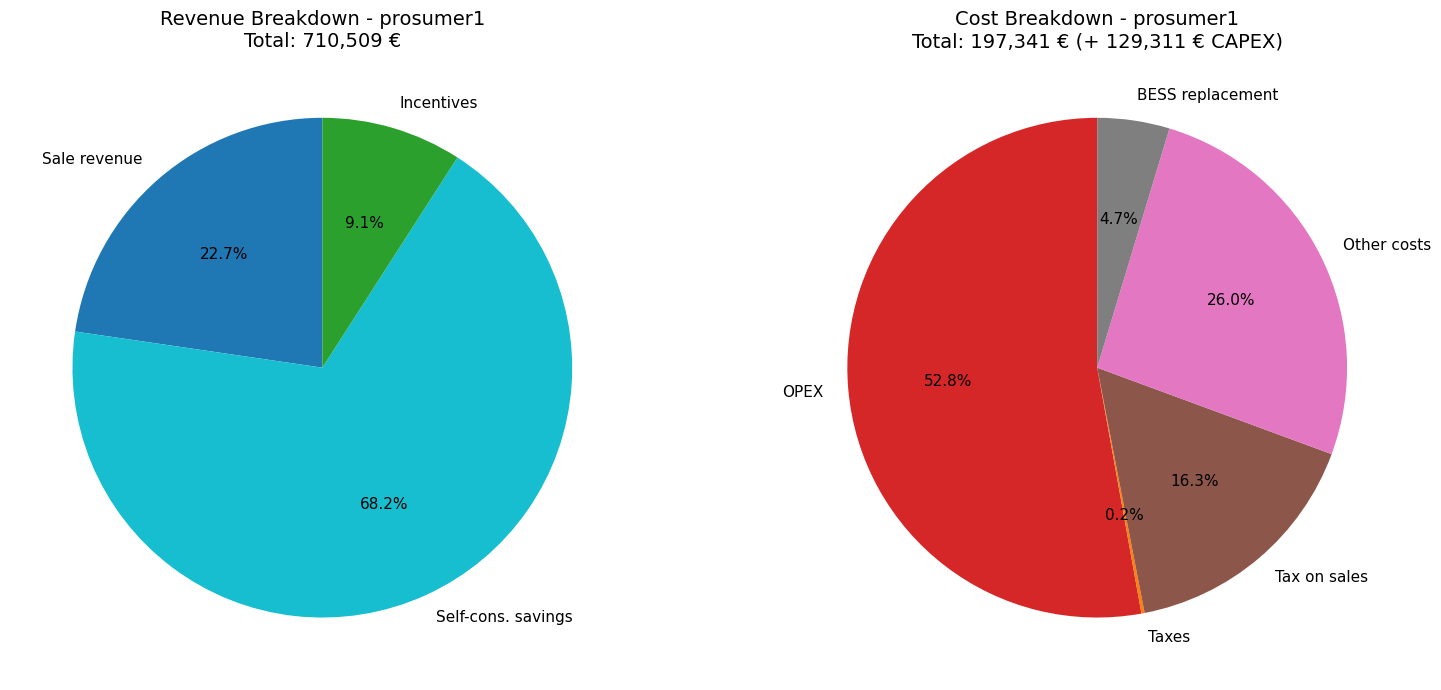

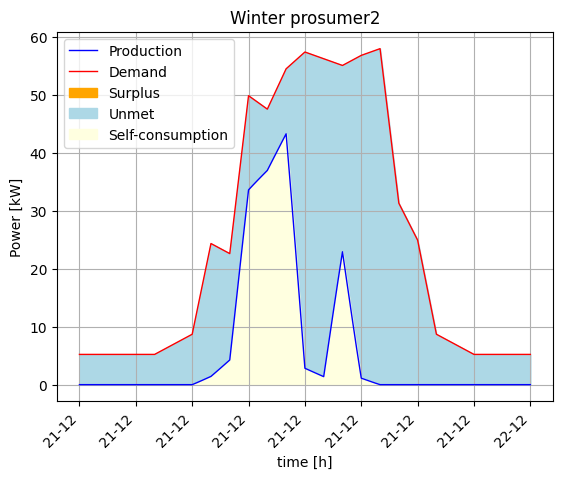

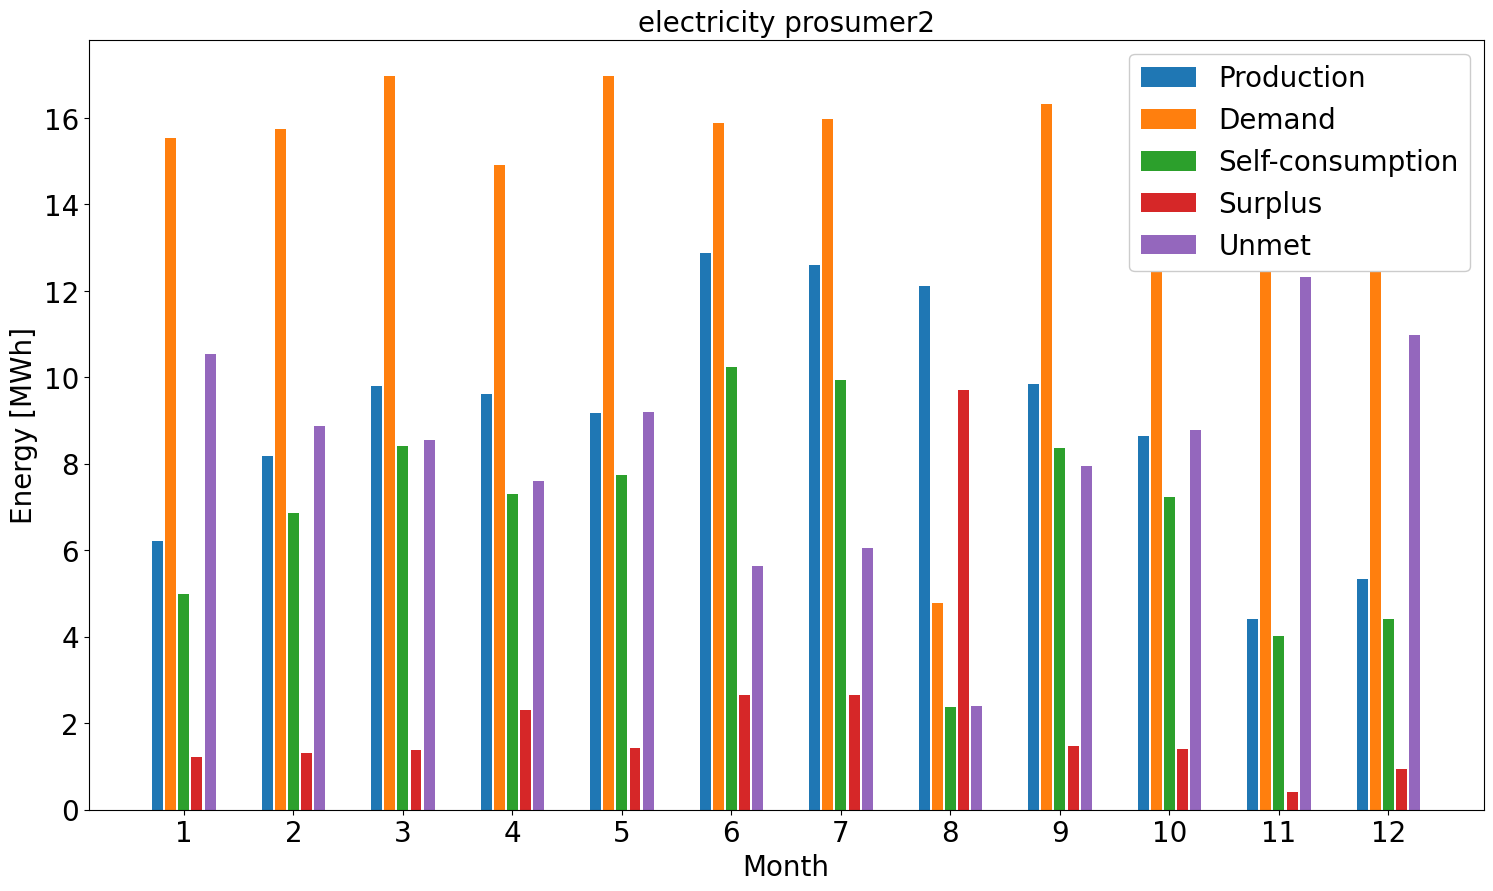

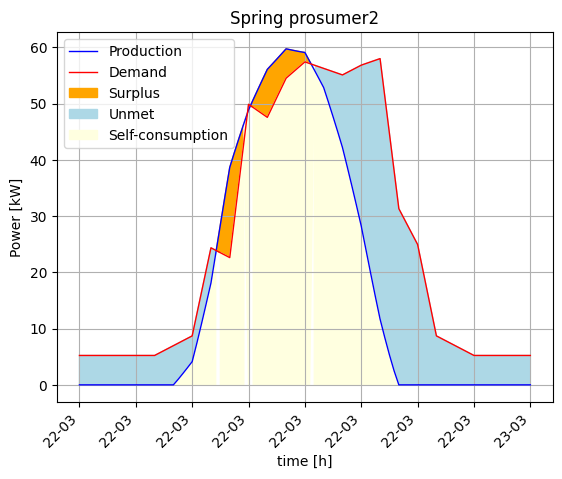

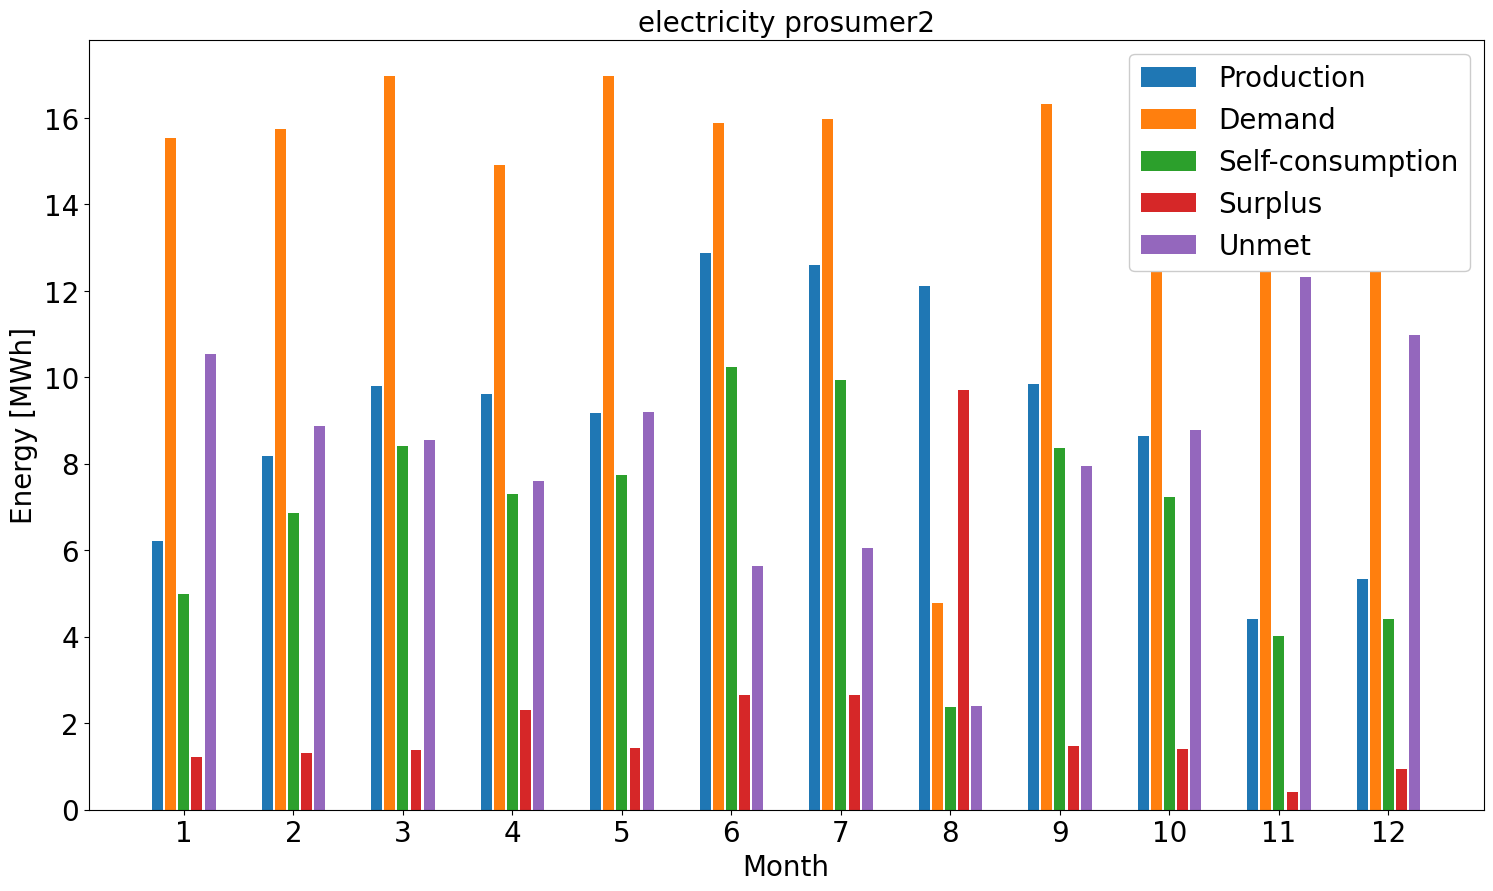

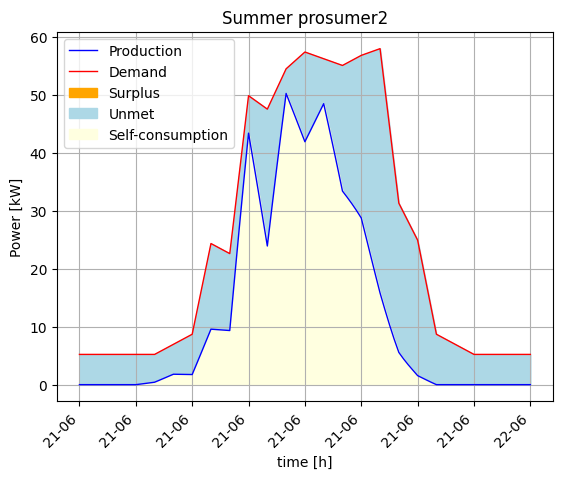

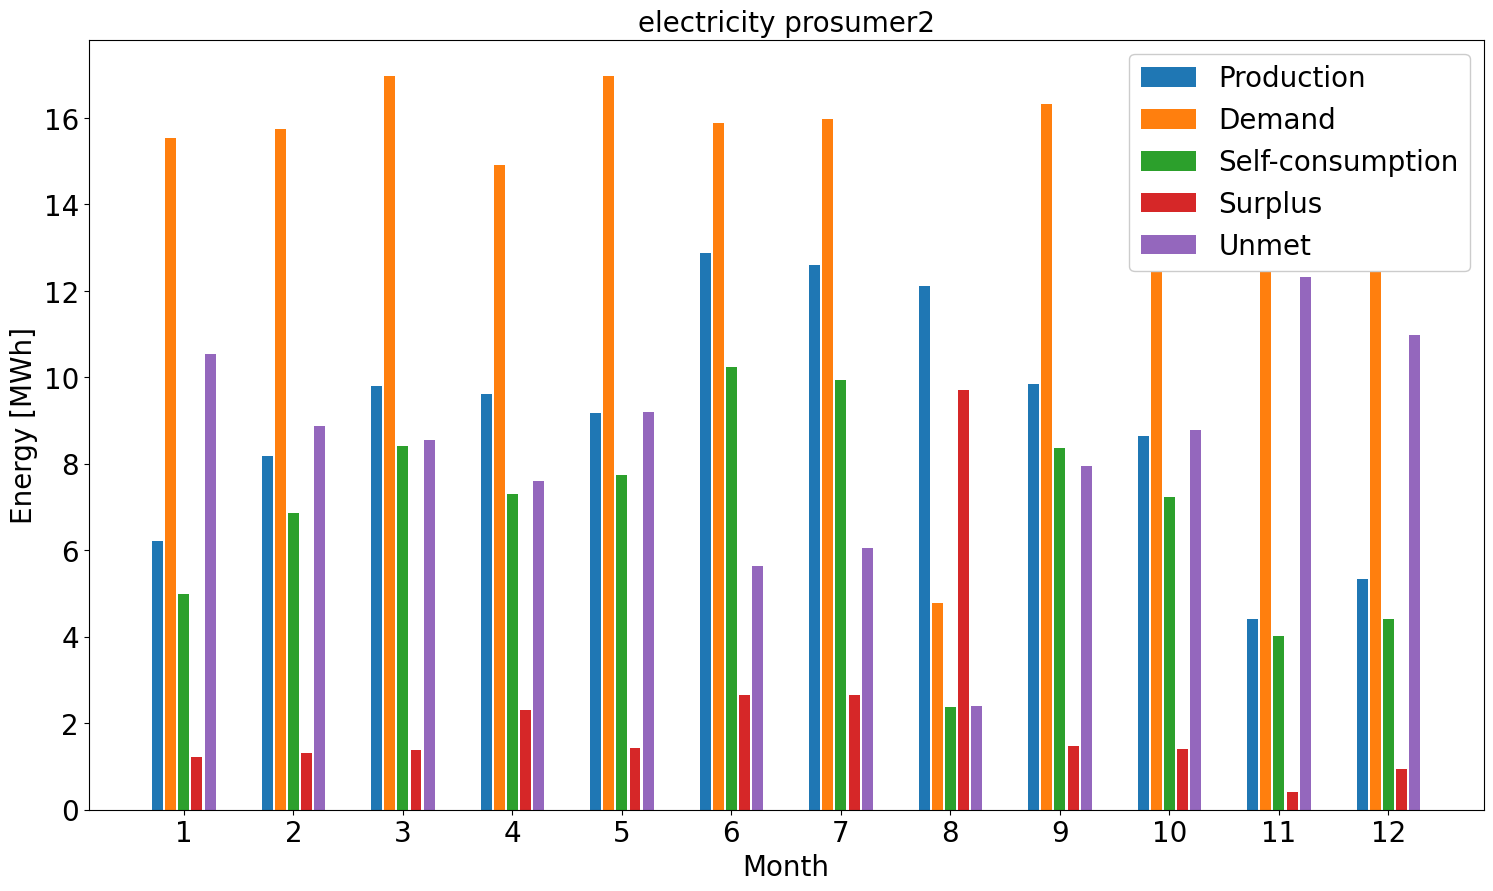

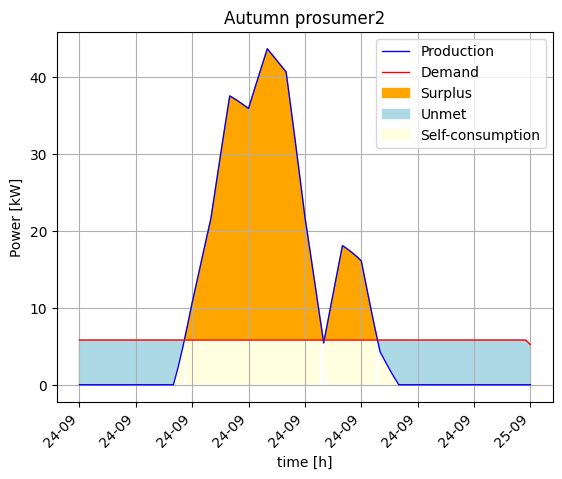

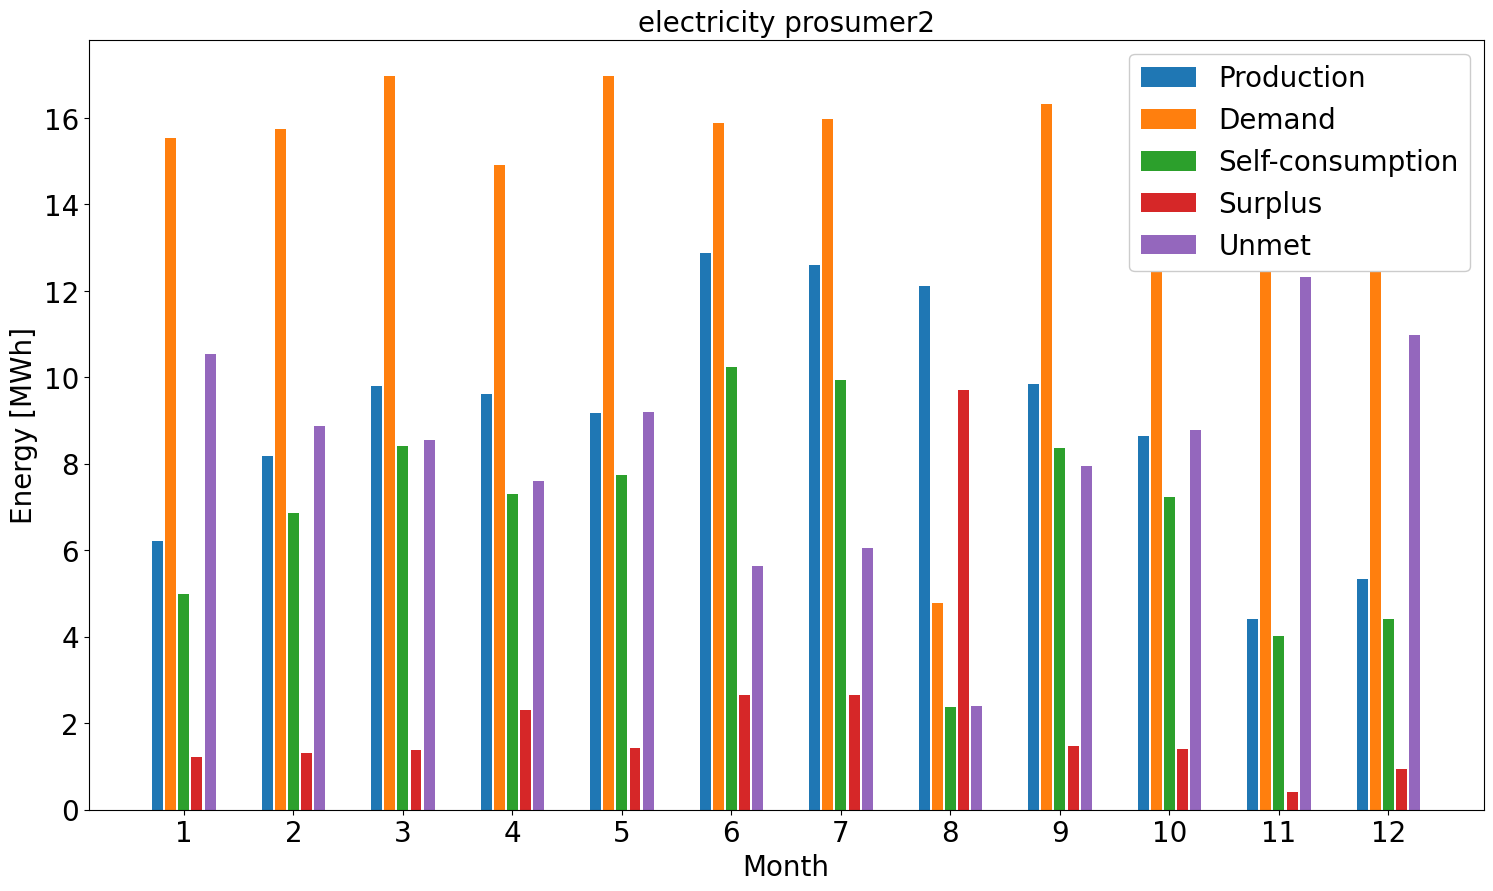

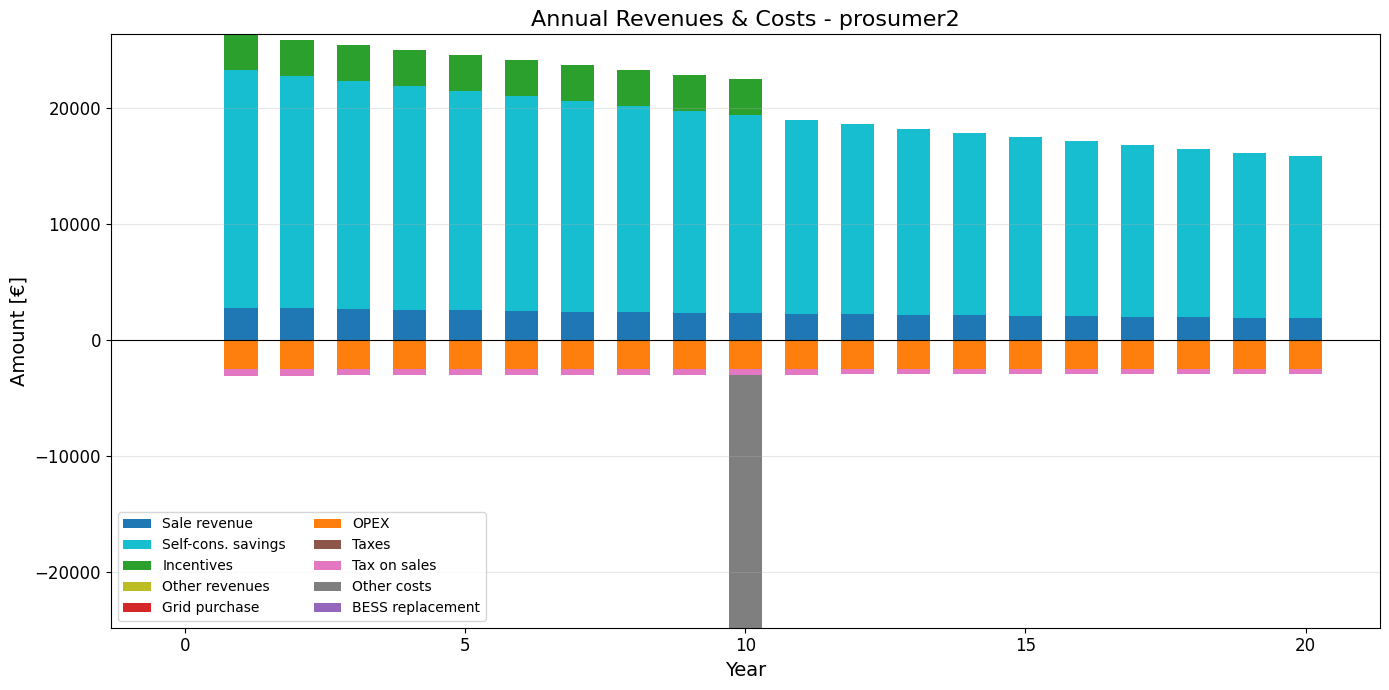

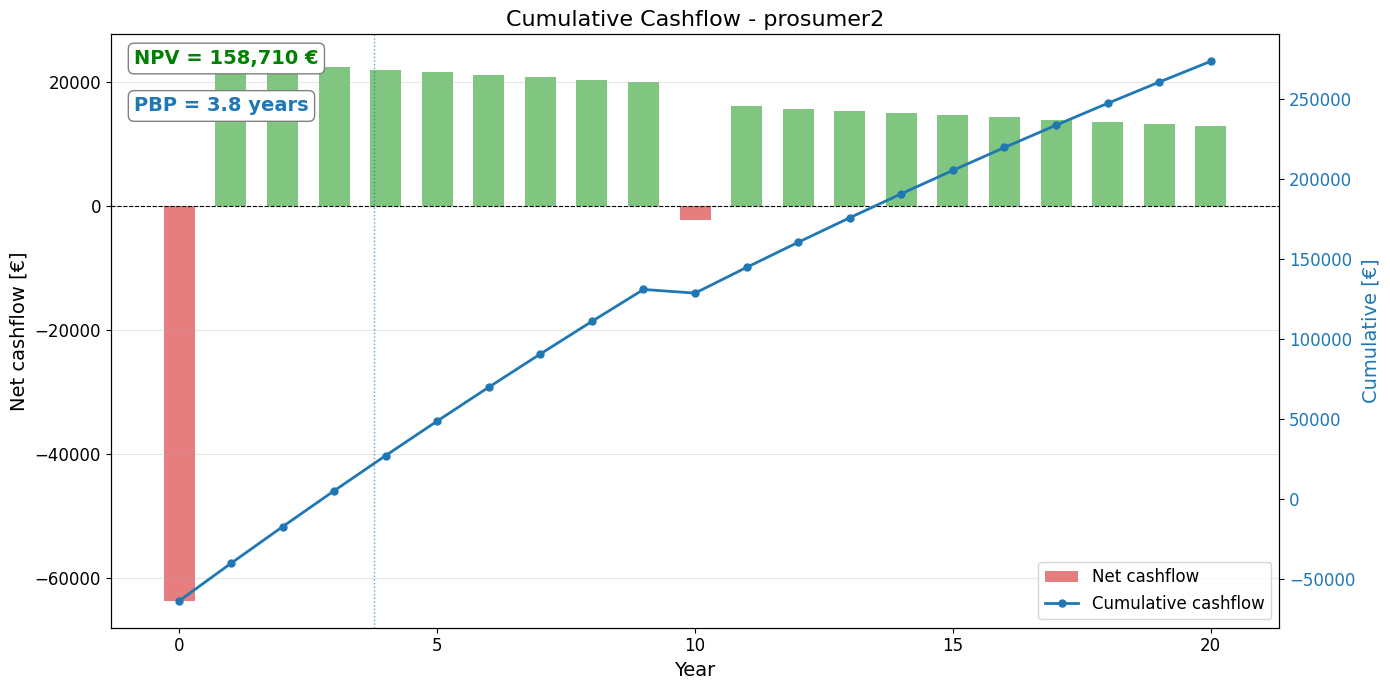

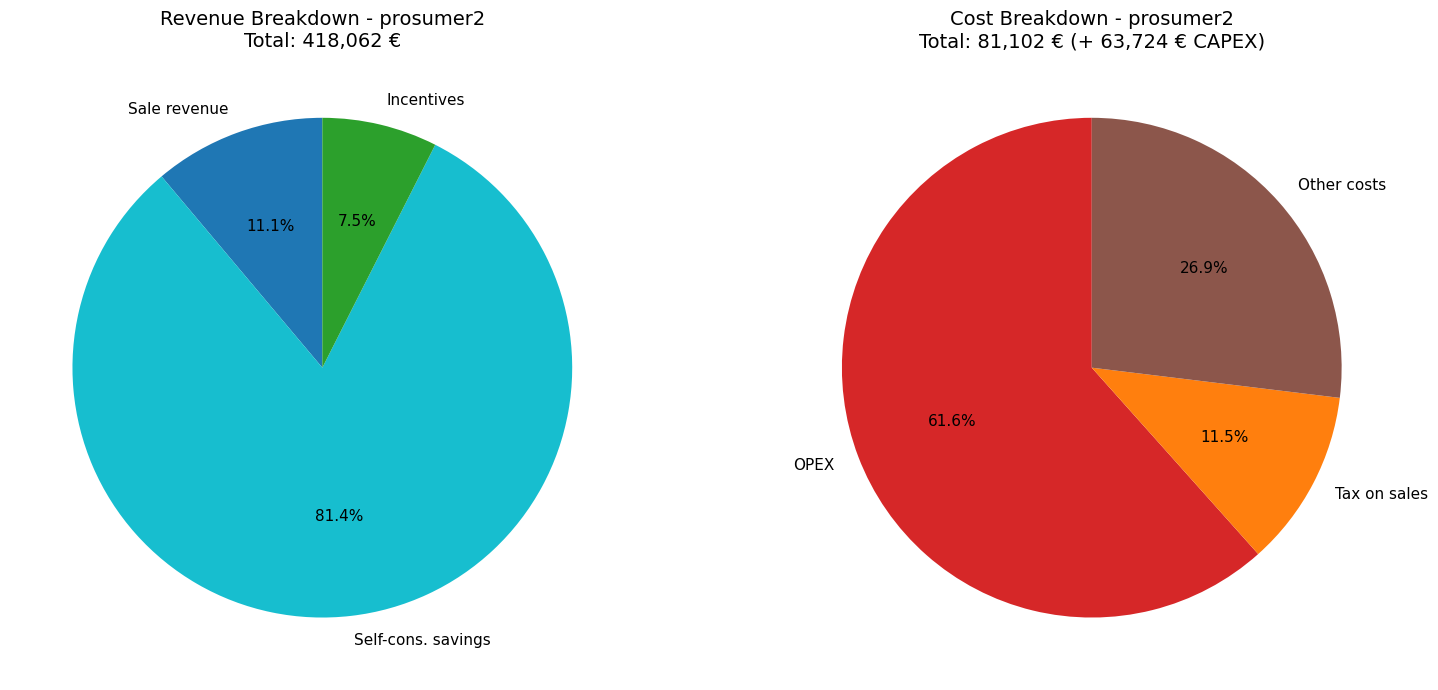

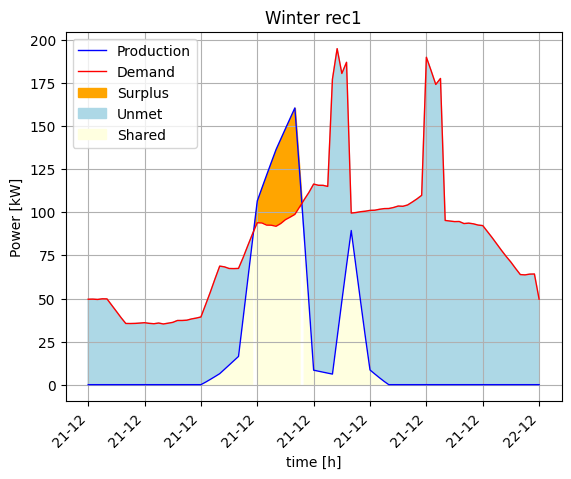

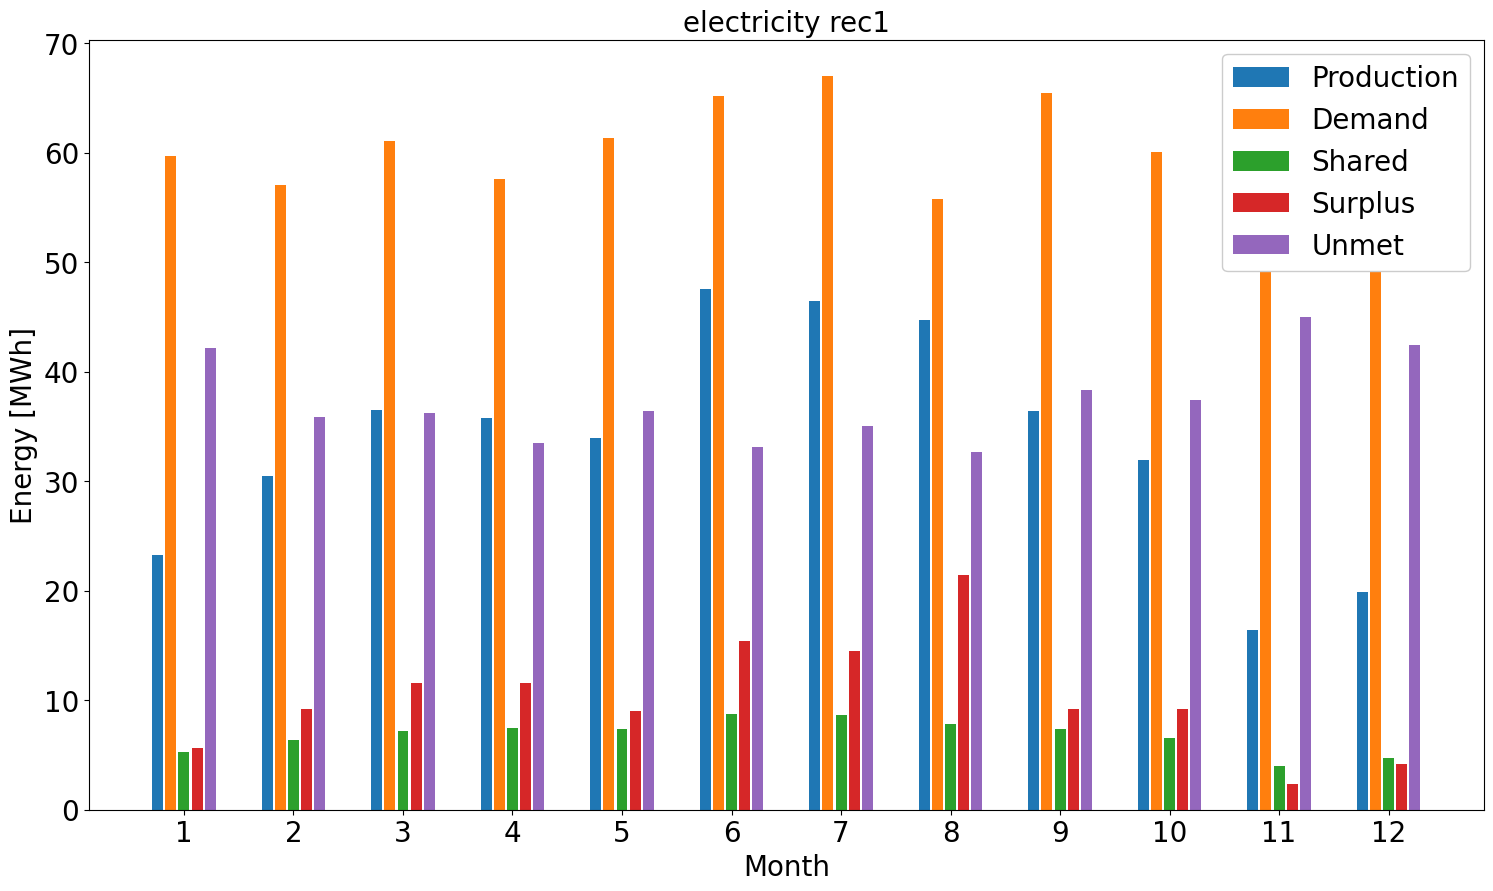

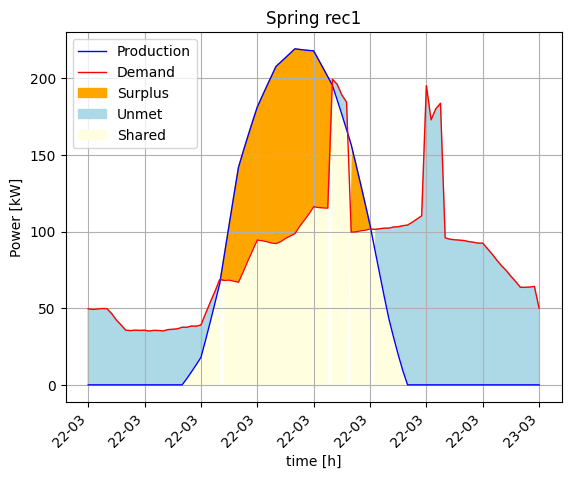

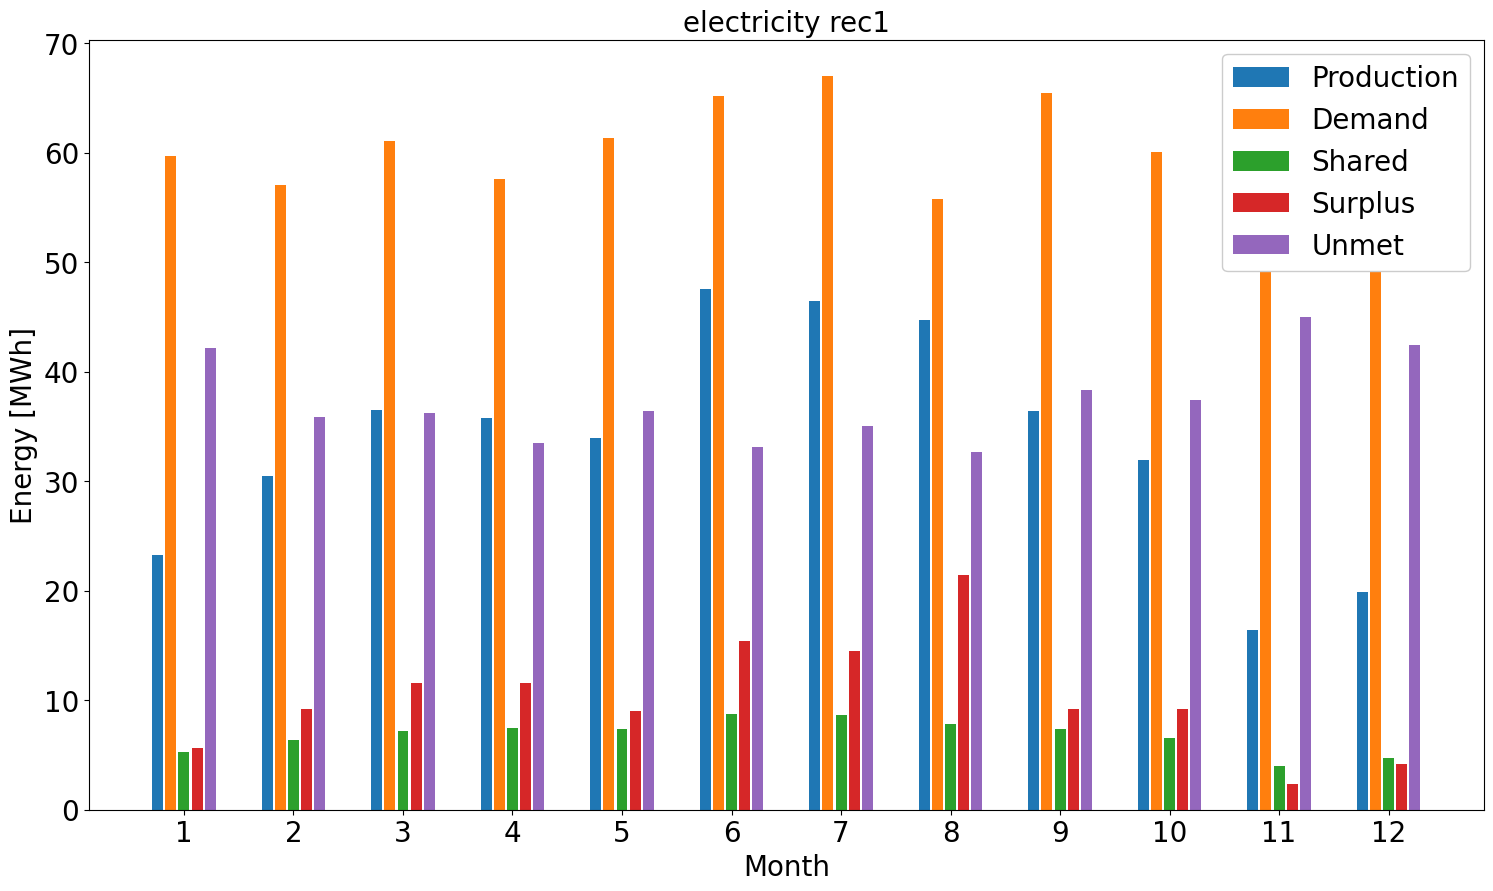

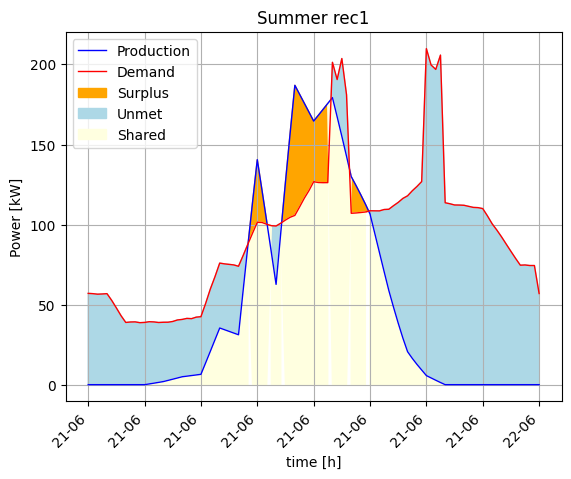

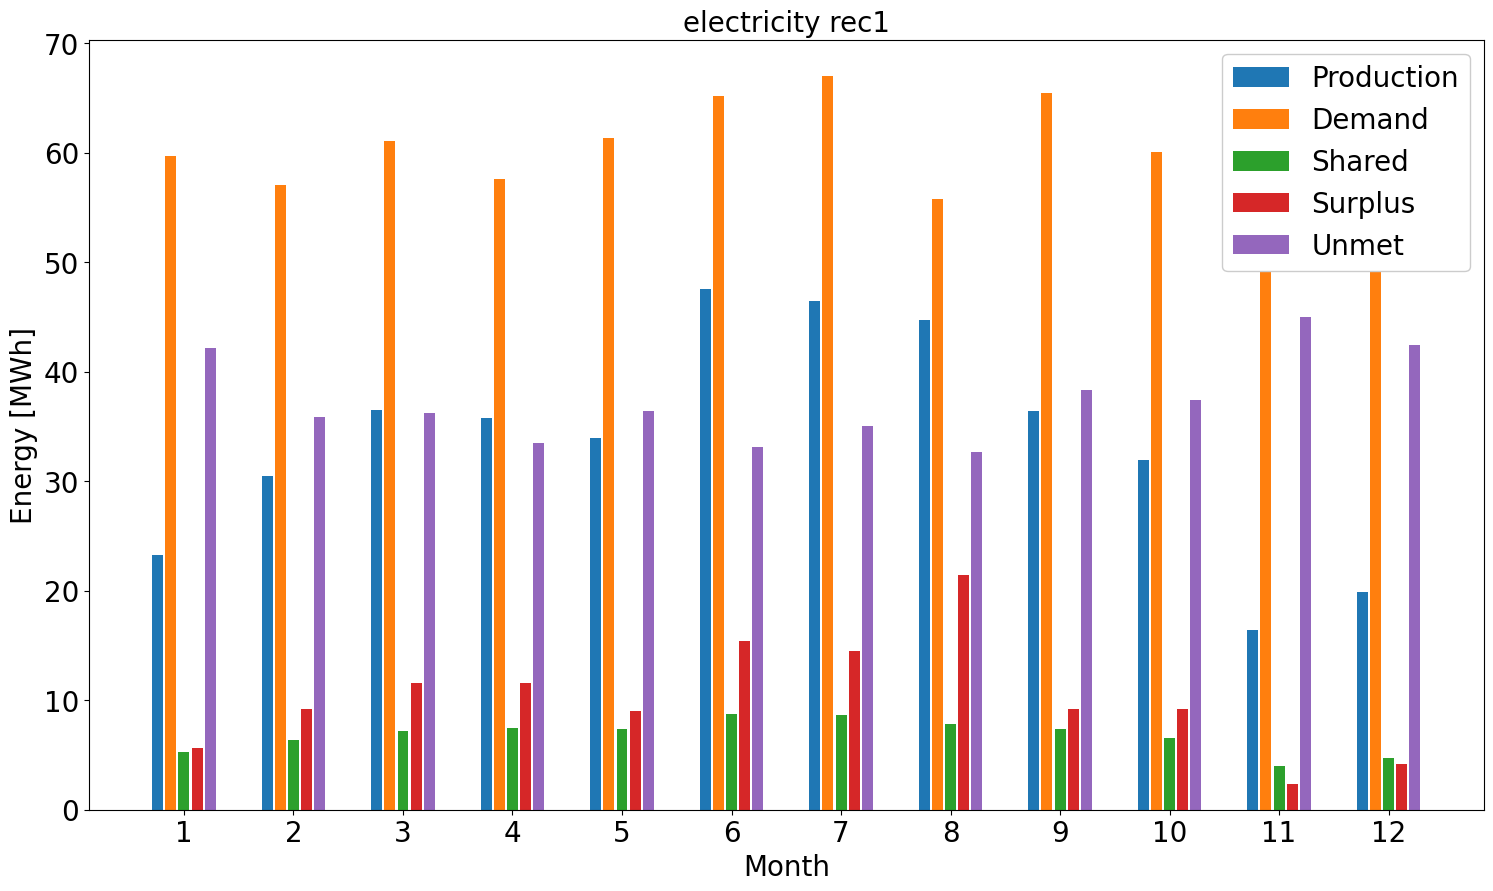

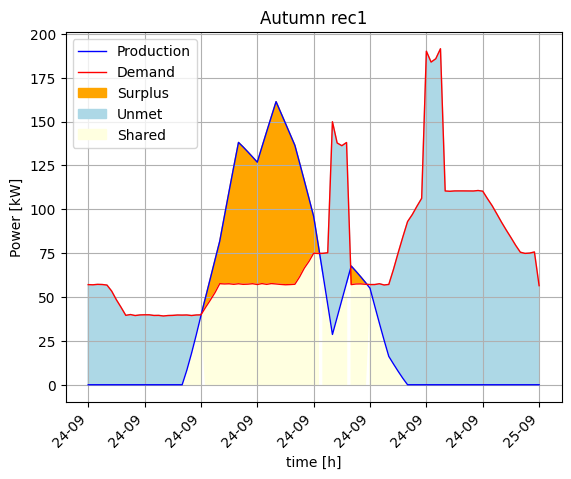

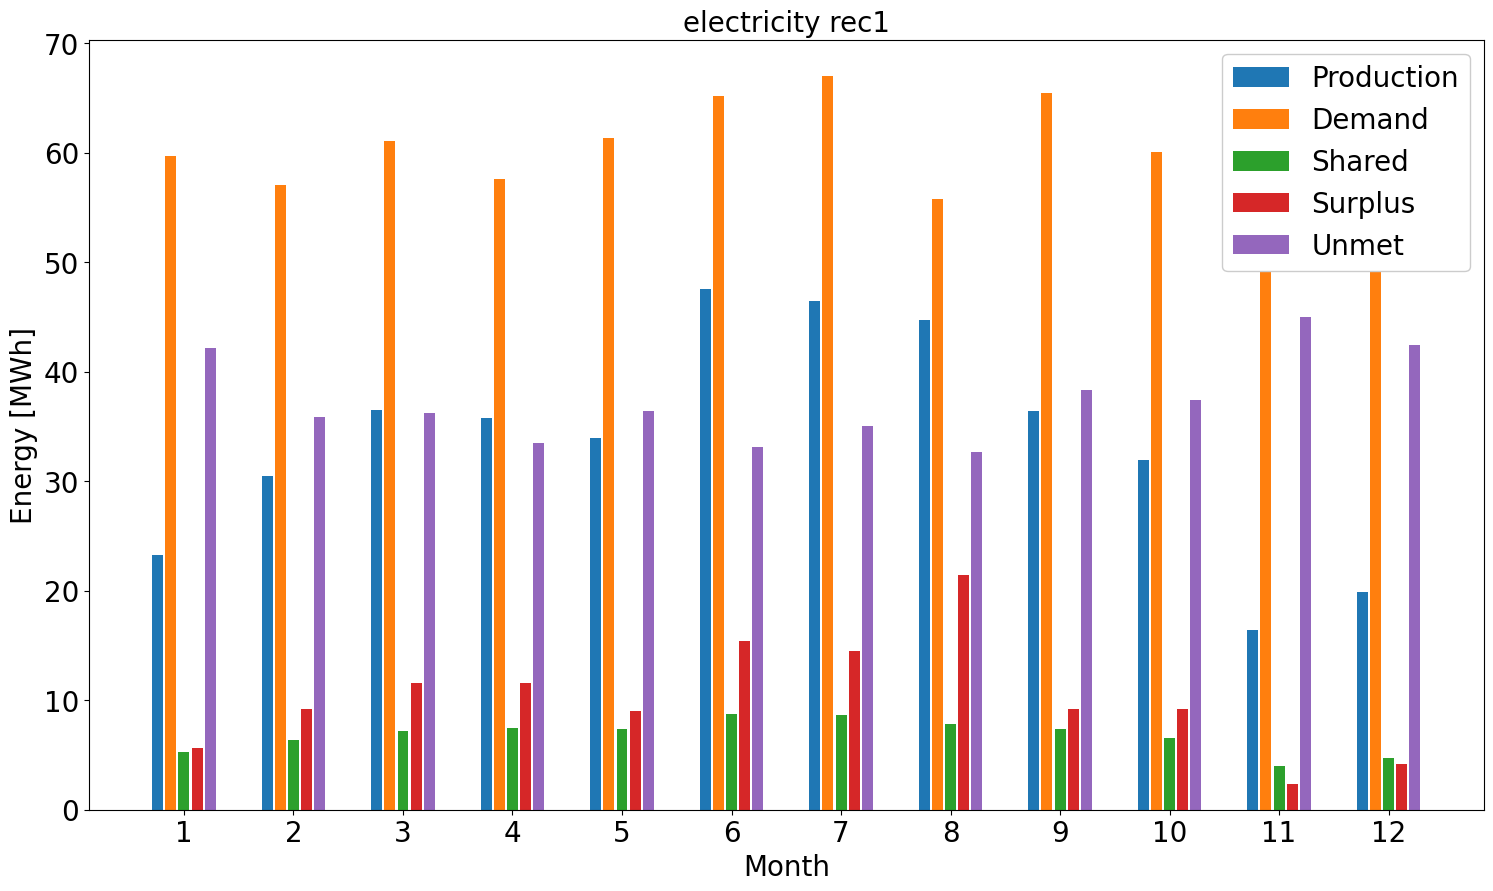

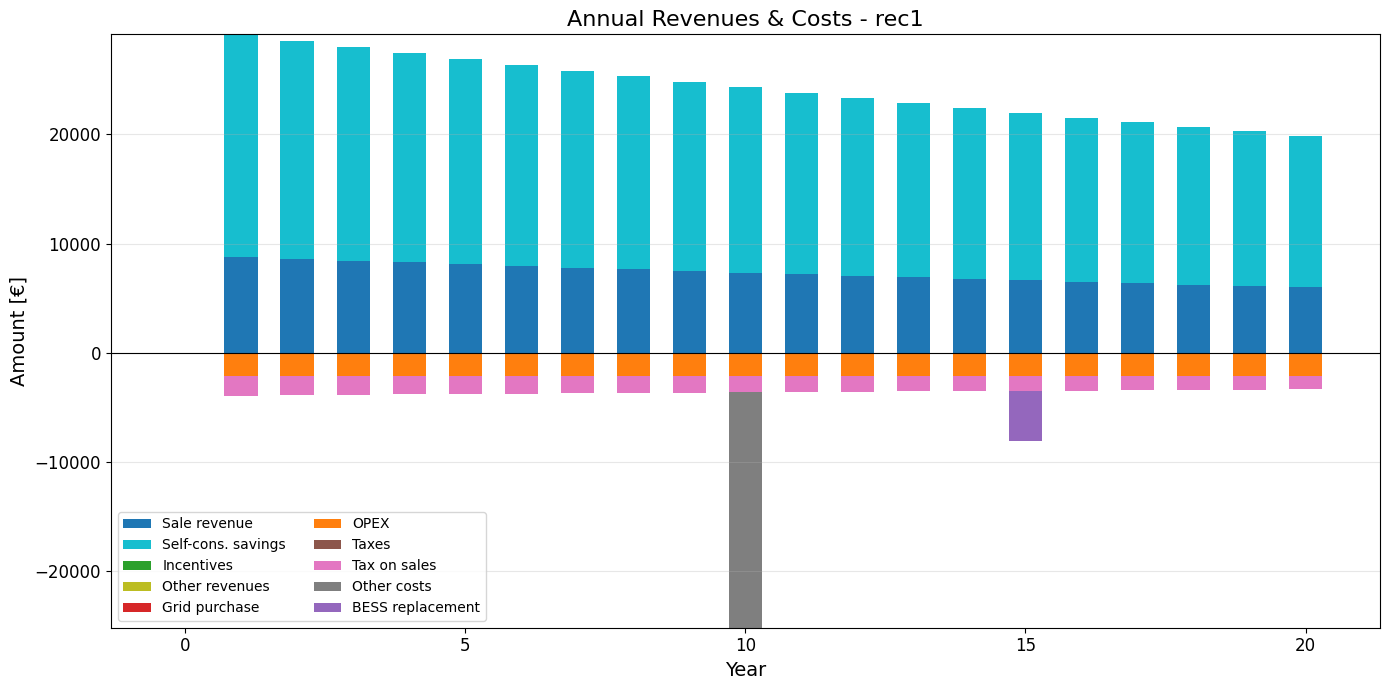

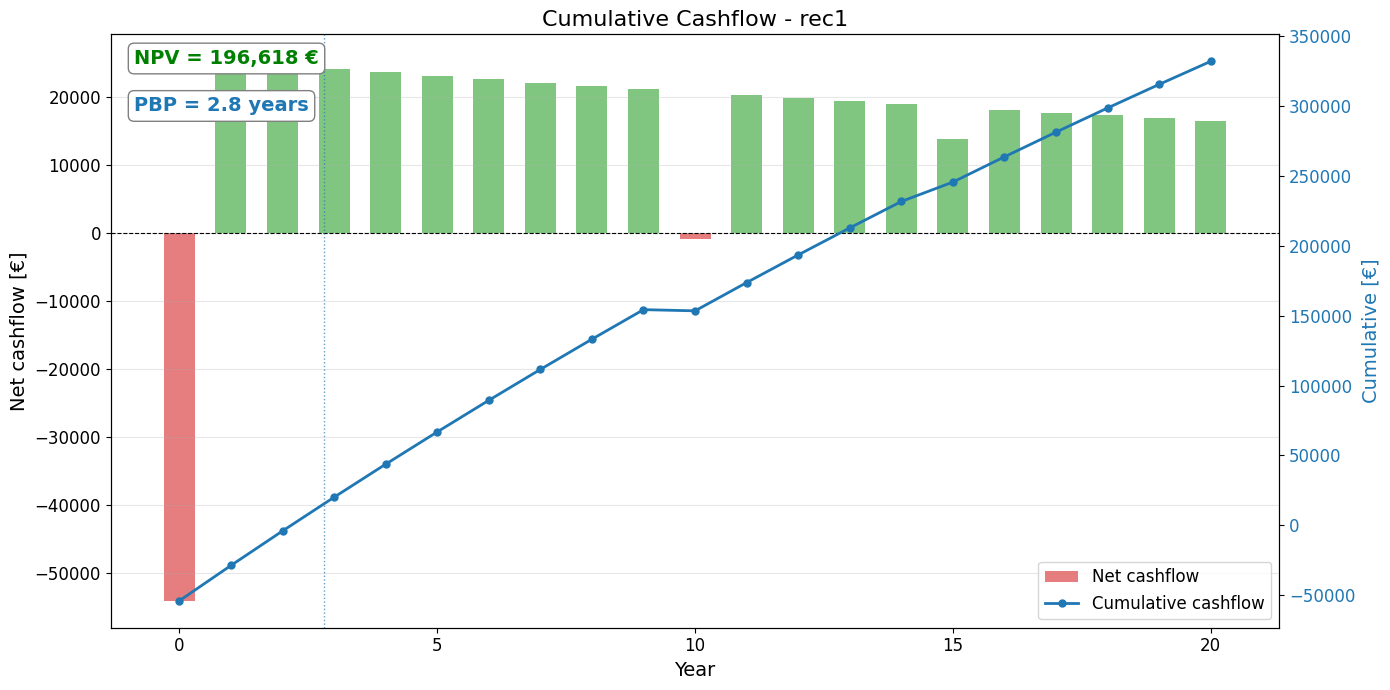

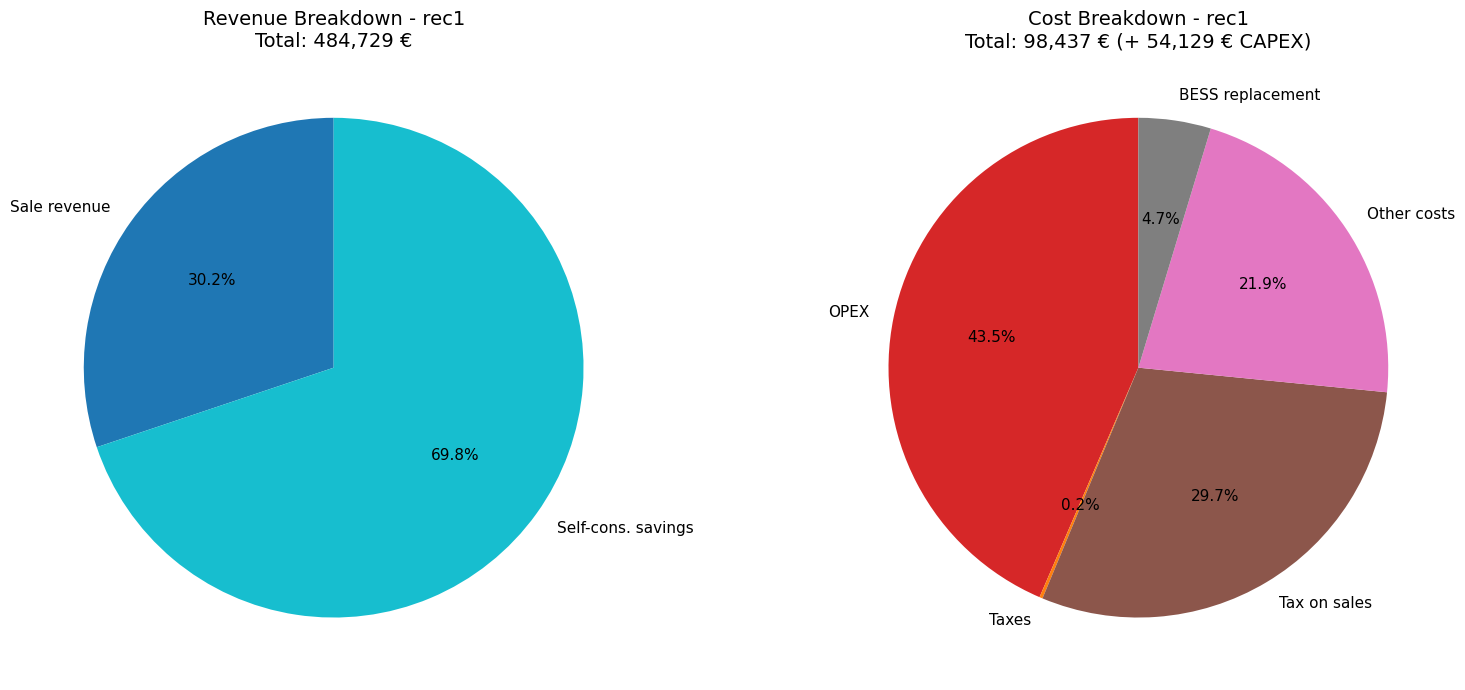

In [14]:
from src.kernel.plot_result import  * # import the plot function to visualize results
import os
file_path_yaml = "Input/config.yaml" # read the YAML configuration docs from the Input folder
output_dir = Path(os.path.join(test_base,"Output/")) # specify the Output folder for saving results
simulation, all_components, rec_result, pros_result, rec_result_ec, pros_result_ec = run(file_path_yaml, base_path=test_base, output_dir=output_dir) # run the simulation
# Change the current working directory to the test_base folder
original_dir = os.getcwd()
os.chdir(test_base)

try:
    plot(simulation, all_components)
finally:
    # Restore the original working directory
    os.chdir(original_dir)

---
---

## **Step 5 - Check Results**

All simulation outputs are saved in:

```text
tutorials/example_model/"test_base"/Output/
```

You'll find:

**Energy plots:**
- Seasonal plots for each prosumer (`prosumer1_electricity_Winter.png`, etc.)
- Bar plots summarizing annual performance (`prosumer1_electricity_bar.png`, etc.)
- Aggregated results for the REC (`rec1_electricity_Winter.png`, `rec1_electricity_bar.png`, etc.)

**Economic plots:**
- Annual cashflow (`prosumer1_cashflow_annual.png`, etc.)
- Cumulative cashflow (`prosumer1_cashflow_cumulative.png`, etc.)
- Economic breakdown (`prosumer1_economic_breakdown.png`, etc.)

**Data files:**
- `prosumers_en_perf_evolution_kW.csv` — time series of energy flows for each prosumer
- `recs_en_perf_evolution_kW.csv` — time series of energy flows for each REC
- `prosumers_ec_perf_€.xlsx` — economic performance for each prosumer
- `recs_ec_perf_€.xlsx` — economic performance for each REC
- `environmental_summary.xlsx` — environmental performance summary (prosumer, REC, aggregated, GWP, CRM, key indicators)
- `environmental_summary.html` — environmental performance HTML report


---
---

---
---

## **Step 6 - Summary Table: Energy, Economic & Environmental Performance**

This section displays a comprehensive summary of the REC simulation results by calling `summary()` on each prosumer and REC object. The summary includes:
- **Energy performance**: annual production, consumption, self-consumption, shared energy, surplus, purchased (MWh/y), SC and SS rates
- **Economic performance**: CAPEX, NPV, Payback Period
- **Environmental performance**: CO2 avoided, GWP embodied/net, CO2 payback time, lifecycle emission factor, CRM totals

An **aggregated table** combines prosumer and REC data with a TOTAL row computed from all assets (prosumer + REC-owned).

The fossil fuel savings are estimated using the average fuel mix of the Italian electricity grid (source: Terna/ISPRA 2023):
- **Natural gas**: around 49% of Italian electricity generation (~0.187 m³/kWh thermal efficiency)
- **Oil/petroleum products**: around 4% (around0.220 kg/kWh thermal efficiency)
- **Coal**: around 4% (0.325 kg/kWh thermal efficiency)

Each kWh of renewable energy produced displaces the equivalent amount of fossil-fuel electricity according to this mix.


The tables above summarize the key performance indicators of the REC simulation:

| Indicator | Description |
|-----------|-------------|
| **Self-cons. rate** | Share of production consumed locally (higher = less grid dependency) |
| **Self-suff. rate** | Share of demand covered by local production (higher = more autonomy) |
| **Shared energy** | Energy exchanged among REC members (incentivized under Italian regulation) |
| **CO2 avoided** | Estimated reduction in CO2 emissions from displacing grid electricity with renewables |

The **fossil fuel savings** are computed as follows: each kWh of renewable energy displaces a fraction of fossil-fuel generation according to the Italian grid mix. The fuel consumption per displaced kWh is estimated from average thermal plant efficiencies:

| Fuel | Grid share | Consumption rate | Efficiency |
|------|-----------|-----------------|------------|
| Natural gas | 49% | 0.187 m³/kWh_el | ~45% |
| Oil / petroleum products | 4% | 0.220 kg/kWh_el | ~38% |
| Coal | 4% | 0.325 kg/kWh_el | ~37% |

The remaining ~43% of Italian electricity comes from renewables (hydro, wind, solar, geothermal) and imports, which do not involve fossil fuel combustion.

Sources: Terna - Statistical data on Italian electricity system; ISPRA - National Inventory Report (NIR) 2023.

The `CO2_GRID_EMISSION_FACTOR` (default: 256 gCO2/kWh) and the `GRID_FUEL_MIX` dictionary can be updated based on the most recent Terna/ISPRA data.

### Critical Raw Materials (CRM)

The **CRM estimates** quantify the materials embedded in PV and BESS manufacturing, based on cradle-to-gate LCA studies:

| Component | Material | Intensity | Source |
|-----------|----------|-----------|--------|
| **PV (c-Si)** | Silicon (metallurgical) | 3.5 kg/kWp | IEA PVPS Task 12 (2020) |
| | Silver | 16 g/kWp | ITRPV Roadmap (2023) |
| | Copper | 4.5 kg/kWp | IEA PVPS Task 12 (2020) |
| | Aluminium (frame) | 20 kg/kWp | IEA PVPS Task 12 (2020) |
| | Lead (solder) | 0.45 kg/kWp | Fthenakis et al. (2012) |
| | Tin (solder) | 0.12 kg/kWp | Fthenakis et al. (2012) |
| **BESS (Li-ion NMC)** | Lithium (Li₂CO₃ eq.) | 0.60 kg/kWh | Dai et al., ANL (2019) |
| | Cobalt | 0.20 kg/kWh | Dai et al., ANL (2019) |
| | Nickel | 0.40 kg/kWh | Dai et al., ANL (2019) |
| | Manganese | 0.15 kg/kWh | EU JRC CRM Report (2020) |
| | Graphite (anode) | 0.80 kg/kWh | Dai et al., ANL (2019) |
| | Copper | 0.80 kg/kWh | IRENA (2023) |

**Note:** BESS values assume NMC (Nickel-Manganese-Cobalt) chemistry. LFP (Lithium Iron Phosphate) batteries would show zero Cobalt, Nickel, and Manganese but similar Lithium and Graphite intensities. The `CRM_PV_PER_KWP` and `CRM_BESS_PER_KWH` dictionaries can be customized for different technologies.

---
---